In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing Library

In [3]:

from keras.models import Sequential
from keras.layers import SeparableConv1D, MaxPooling1D, LSTM, Dense, Dropout
from keras.regularizers import l2
from keras.optimizers import Adam
# module imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import random
from sklearn.decomposition import PCA

# model imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import KernelPCA


# processing imports
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from tensorflow.keras.utils import to_categorical

from keras.layers import Dense, LSTM, MaxPool1D, Flatten, Dropout # importing dense layer
from keras.models import Sequential #importing Sequential layer
from keras.layers import Input
from keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.layers import Embedding
from keras.layers import LSTM
from keras.layers import Conv1D, MaxPooling1D
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score,classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import train_test_split

import lightgbm as lgb
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout, multiply, Concatenate
from tensorflow.keras.layers import BatchNormalization, Activation, Embedding, ZeroPadding2D, LeakyReLU
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
import tensorflow.keras.backend as K
from sklearn.utils import shuffle

np.random.seed(1635848)

# model = Sequential()

# # DS-CNN Block 1
# model.add(SeparableConv1D(
#     filters=64,
#     kernel_size=3,
#     padding="same",
#     input_shape=(X_DoS.shape[1], 1),
#     activation='relu',
#     depthwise_regularizer=l2(0.01),
#     pointwise_regularizer=l2(0.01)
# ))
# model.add(SeparableConv1D(
#     filters=64,
#     kernel_size=3,
#     padding="same",
#     activation='relu',
#     depthwise_regularizer=l2(0.01),
#     pointwise_regularizer=l2(0.01)
# ))
# model.add(MaxPooling1D(pool_size=2))

# # DS-CNN Block 2
# model.add(SeparableConv1D(
#     filters=128,
#     kernel_size=3,
#     padding="same",
#     activation='relu',
#     depthwise_regularizer=l2(0.01),
#     pointwise_regularizer=l2(0.01)
# ))
# model.add(SeparableConv1D(
#     filters=128,
#     kernel_size=3,
#     padding="same",
#     activation='relu',
#     depthwise_regularizer=l2(0.01),
#     pointwise_regularizer=l2(0.01)
# ))
# model.add(MaxPooling1D(pool_size=2))

# # LSTM
# model.add(LSTM(
#     units=100,
#     return_sequences=False,
#     dropout=0.1,
#     kernel_regularizer=l2(0.01)
# ))

# model.add(Dropout(0.5))
# model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01)))

# opt = Adam(learning_rate=initial_learning_rate)
# model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# model.summary()


In [4]:
# fetch the training file
file_path_full_training_set = '/content/KDDTrain+.txt'
file_path_test = '/content/KDDTest+.txt'
# file_path_full_training_set = '/content/drive/MyDrive/NSL-KDD/KDDTrain+.txt'
# file_path_test = '/content/drive/MyDrive/NSL-KDD/KDDTest+.txt'

In [5]:
!cd /content
!wget https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt
!wget https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt

--2026-04-23 08:57:58--  https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19109424 (18M) [text/plain]
Saving to: ‘KDDTrain+.txt’

KDDTrain+.txt       100%[===================>]  18.22M  --.-KB/s    in 0.1s    

2026-04-23 08:57:59 (186 MB/s) - ‘KDDTrain+.txt’ saved [19109424/19109424]

--2026-04-23 08:57:59--  https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3441513 (3.3M) [text/plain]
Saving

In [6]:
#df = pd.read_csv(file_path_20_percent)
df = pd.read_csv(file_path_full_training_set)
test_df = pd.read_csv(file_path_test)

# add the column labels
columns = (['duration'
,'protocol_type'
,'service'
,'flag'
,'src_bytes'
,'dst_bytes'
,'land'
,'wrong_fragment'
,'urgent'
,'hot'
,'num_failed_logins'
,'logged_in'
,'num_compromised'
,'root_shell'
,'su_attempted'
,'num_root'
,'num_file_creations'
,'num_shells'
,'num_access_files'
,'num_outbound_cmds'
,'is_host_login'
,'is_guest_login'
,'count'
,'srv_count'
,'serror_rate'
,'srv_serror_rate'
,'rerror_rate'
,'srv_rerror_rate'
,'same_srv_rate'
,'diff_srv_rate'
,'srv_diff_host_rate'
,'dst_host_count'
,'dst_host_srv_count'
,'dst_host_same_srv_rate'
,'dst_host_diff_srv_rate'
,'dst_host_same_src_port_rate'
,'dst_host_srv_diff_host_rate'
,'dst_host_serror_rate'
,'dst_host_srv_serror_rate'
,'dst_host_rerror_rate'
,'dst_host_srv_rerror_rate'
,'attack'
,'level'])

In [7]:
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [8]:
df.columns = columns
test_df.columns = columns

In [9]:
df.shape

(125972, 43)

In [10]:
test_df.shape

(22543, 43)

In [11]:
pd.set_option('display.max_columns', 43)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [12]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack', 'level'],
      dtype='object')

In [13]:
test_df.shape

(22543, 43)

In [14]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125972.000000,1.259720e+05,1.259720e+05,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.0,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,4.556710e+04,1.977927e+04,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,0.001342,0.001103,0.302194,0.012669,0.000413,0.004096,0.0,0.000008,0.009423,84.108207,27.738093,0.284487,0.282488,0.119959,0.121184,0.660925,0.063053,0.097322,182.149200,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5.870354e+06,4.021285e+06,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,0.036603,0.045155,24.399715,0.483937,0.022181,0.099370,0.0,0.002817,0.096613,114.508828,72.636092,0.446457,0.447024,0.320437,0.323648,0.439624,0.180315,0.259831,99.206565,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.0,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [15]:
print(df.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack', 'level'],
      dtype='object')


In [16]:
pd.set_option('display.max_rows', 23)
print('Label distribution Training set:')
print(df['attack'].value_counts())

Label distribution Training set:
attack
normal             67342
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [17]:
print('Label distribution Test set:')
print(test_df['attack'].value_counts())

Label distribution Test set:
attack
normal          9711
neptune         4656
guess_passwd    1231
mscan            996
warezmaster      944
                ... 
perl               2
sqlattack          2
udpstorm           2
phf                2
imap               1
Name: count, Length: 38, dtype: int64


In [18]:
# colums that are categorical and not binary yet: protocol_type (column 2), service (column 3), flag (column 4).
# explore categorical features
print('Training set:')
for col_name in df.columns:
    if df[col_name].dtypes == 'object' :
        unique_cat = len(df[col_name].unique())
        print("Feature '{col_name}' has {unique_cat} categories".format(col_name=col_name, unique_cat=unique_cat))

#see how distributed the feature service is, it is evenly distributed and therefore we need to make dummies for all.
print()
print('Distribution of categories in service:')
print(df['service'].value_counts().sort_values(ascending=False).head())

Training set:
Feature 'protocol_type' has 3 categories
Feature 'service' has 70 categories
Feature 'flag' has 11 categories
Feature 'attack' has 23 categories

Distribution of categories in service:
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6859
Name: count, dtype: int64


In [19]:
# Test set
print('Test set:')
for col_name in test_df.columns:
    if test_df[col_name].dtypes == 'object' :
        unique_cat = len(test_df[col_name].unique())
        print("Feature '{col_name}' has {unique_cat} categories".format(col_name=col_name, unique_cat=unique_cat))

Test set:
Feature 'protocol_type' has 3 categories
Feature 'service' has 64 categories
Feature 'flag' has 11 categories
Feature 'attack' has 38 categories


In [20]:

from sklearn.preprocessing import LabelEncoder,OneHotEncoder
categorical_columns=['protocol_type', 'service', 'flag']
# insert code to get a list of categorical columns into a variable, categorical_columns
categorical_columns=['protocol_type', 'service', 'flag']
 # Get the categorical values into a 2D numpy array
df_categorical_values = df[categorical_columns]
testdf_categorical_values = test_df[categorical_columns]
df_categorical_values.head()

,protocol_type,service,flag
0,udp,other,SF
1,tcp,private,S0
2,tcp,http,SF
3,tcp,http,SF
4,tcp,private,REJ


In [21]:
# protocol type
unique_protocol=sorted(df.protocol_type.unique())
string1 = 'Protocol_type_'
unique_protocol2=[string1 + x for x in unique_protocol]
# service
unique_service=sorted(df.service.unique())
string2 = 'service_'
unique_service2=[string2 + x for x in unique_service]
# flag
unique_flag=sorted(df.flag.unique())
string3 = 'flag_'
unique_flag2=[string3 + x for x in unique_flag]
# put together
dumcols=unique_protocol2 + unique_service2 + unique_flag2
print(dumcols)

#do same for test set
unique_service_test=sorted(test_df.service.unique())
unique_service2_test=[string2 + x for x in unique_service_test]
testdumcols=unique_protocol2 + unique_service2_test + unique_flag2

['Protocol_type_icmp', 'Protocol_type_tcp', 'Protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'service_eco_i', 'service_ecr_i', 'service_efs', 'service_exec', 'service_finger', 'service_ftp', 'service_ftp_data', 'service_gopher', 'service_harvest', 'service_hostnames', 'service_http', 'service_http_2784', 'service_http_443', 'service_http_8001', 'service_imap4', 'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap', 'service_link', 'service_login', 'service_mtp', 'service_name', 'service_netbios_dgm', 'service_netbios_ns', 'service_netbios_ssn', 'service_netstat', 'service_nnsp', 'service_nntp', 'service_ntp_u', 'service_other', 'service_pm_dump', 'service_pop_2', 'service_pop_3', 'service_printer', 'service_private', 'service_red_i', 'service_remote_job', 'serv

In [22]:
df_categorical_values_enc=df_categorical_values.apply(LabelEncoder().fit_transform)
print(df_categorical_values_enc.head())
# test set
testdf_categorical_values_enc=testdf_categorical_values.apply(LabelEncoder().fit_transform)

   protocol_type  service  flag
0              2       44     9
1              1       49     5
2              1       24     9
3              1       24     9
4              1       49     1


In [23]:
enc = OneHotEncoder()
df_categorical_values_encenc = enc.fit_transform(df_categorical_values_enc)
df_cat_data = pd.DataFrame(df_categorical_values_encenc.toarray(),columns=dumcols)
# test set
testdf_categorical_values_encenc = enc.fit_transform(testdf_categorical_values_enc)
testdf_cat_data = pd.DataFrame(testdf_categorical_values_encenc.toarray(),columns=testdumcols)

df_cat_data.head()

,Protocol_type_icmp,Protocol_type_tcp,Protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,...,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
trainservice=df['service'].tolist()
testservice= test_df['service'].tolist()
difference=list(set(trainservice) - set(testservice))
string = 'service_'
difference=[string + x for x in difference]
difference

['service_red_i',
 'service_urh_i',
 'service_http_2784',
 'service_http_8001',
 'service_aol',
 'service_harvest']

In [25]:
for col in difference:
    testdf_cat_data[col] = 0

testdf_cat_data.shape

(22543, 84)

In [26]:

newdf=df.join(df_cat_data)
newdf.drop('flag', axis=1, inplace=True)
newdf.drop('protocol_type', axis=1, inplace=True)
newdf.drop('service', axis=1, inplace=True)
# test data
newdf_test=test_df.join(testdf_cat_data)
newdf_test.drop('flag', axis=1, inplace=True)
newdf_test.drop('protocol_type', axis=1, inplace=True)
newdf_test.drop('service', axis=1, inplace=True)
print(newdf.shape)
print(newdf_test.shape)

(125972, 124)
(22543, 124)


In [27]:
newdf.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,...,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# take label column
labeldf=newdf['attack']
labeldf_test=newdf_test['attack']
# change the label column
newlabeldf=labeldf.replace({ 'normal' : 0, 'neptune' : 1 ,'back': 1, 'land': 1, 'pod': 1, 'smurf': 1, 'teardrop': 1,'mailbomb': 1, 'apache2': 1, 'processtable': 1, 'udpstorm': 1, 'worm': 1,
                           'ipsweep' : 2,'nmap' : 2,'portsweep' : 2,'satan' : 2,'mscan' : 2,'saint' : 2
                           ,'ftp_write': 3,'guess_passwd': 3,'imap': 3,'multihop': 3,'phf': 3,'spy': 3,'warezclient': 3,'warezmaster': 3,'sendmail': 3,'named': 3,'snmpgetattack': 3,'snmpguess': 3,'xlock': 3,'xsnoop': 3,'httptunnel': 3,
                           'buffer_overflow': 4,'loadmodule': 4,'perl': 4,'rootkit': 4,'ps': 4,'sqlattack': 4,'xterm': 4})
newlabeldf_test=labeldf_test.replace({ 'normal' : 0, 'neptune' : 1 ,'back': 1, 'land': 1, 'pod': 1, 'smurf': 1, 'teardrop': 1,'mailbomb': 1, 'apache2': 1, 'processtable': 1, 'udpstorm': 1, 'worm': 1,
                           'ipsweep' : 2,'nmap' : 2,'portsweep' : 2,'satan' : 2,'mscan' : 2,'saint' : 2
                           ,'ftp_write': 3,'guess_passwd': 3,'imap': 3,'multihop': 3,'phf': 3,'spy': 3,'warezclient': 3,'warezmaster': 3,'sendmail': 3,'named': 3,'snmpgetattack': 3,'snmpguess': 3,'xlock': 3,'xsnoop': 3,'httptunnel': 3,
                           'buffer_overflow': 4,'loadmodule': 4,'perl': 4,'rootkit': 4,'ps': 4,'sqlattack': 4,'xterm': 4})
# put the new label column back
newdf['attack'] = newlabeldf
newdf_test['attack'] = newlabeldf_test
print(newdf['attack'].head())

0    0
1    1
2    0
3    0
4    1
Name: attack, dtype: int64


/tmp/ipykernel_7755/3327160078.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  newlabeldf=labeldf.replace({ 'normal' : 0, 'neptune' : 1 ,'back': 1, 'land': 1, 'pod': 1, 'smurf': 1, 'teardrop': 1,'mailbomb': 1, 'apache2': 1, 'processtable': 1, 'udpstorm': 1, 'worm': 1,
/tmp/ipykernel_7755/3327160078.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  newlabeldf_test=labeldf_test.replace({ 'normal' : 0, 'neptune' : 1 ,'back': 1, 'land': 1, 'pod': 1, 'smurf': 1, 'teardrop': 1,'mailbomb': 1, 'apache2': 1, 'processtable': 1, 'udpst

In [29]:
to_drop_DoS = [2,3,4]
to_drop_Probe = [1,3,4]
to_drop_R2L = [1,2,4]
to_drop_U2R = [1,2,3]
DoS_df=newdf[~newdf['attack'].isin(to_drop_DoS)];
Probe_df=newdf[~newdf['attack'].isin(to_drop_Probe)];
R2L_df=newdf[~newdf['attack'].isin(to_drop_R2L)];
U2R_df=newdf[~newdf['attack'].isin(to_drop_U2R)];

#test
DoS_df_test=newdf_test[~newdf_test['attack'].isin(to_drop_DoS)];
Probe_df_test=newdf_test[~newdf_test['attack'].isin(to_drop_Probe)];
R2L_df_test=newdf_test[~newdf_test['attack'].isin(to_drop_R2L)];
U2R_df_test=newdf_test[~newdf_test['attack'].isin(to_drop_U2R)];
print('Train:')
print('Dimensions of DoS:' ,DoS_df.shape)
print('Dimensions of Probe:' ,Probe_df.shape)
print('Dimensions of R2L:' ,R2L_df.shape)
print('Dimensions of U2R:' ,U2R_df.shape)
print('Test:')
print('Dimensions of DoS:' ,DoS_df_test.shape)
print('Dimensions of Probe:' ,Probe_df_test.shape)
print('Dimensions of R2L:' ,R2L_df_test.shape)
print('Dimensions of U2R:' ,U2R_df_test.shape)

Train:
Dimensions of DoS: (113269, 124)
Dimensions of Probe: (78998, 124)
Dimensions of R2L: (68337, 124)
Dimensions of U2R: (67394, 124)
Test:
Dimensions of DoS: (17170, 124)
Dimensions of Probe: (12132, 124)
Dimensions of R2L: (12596, 124)
Dimensions of U2R: (9778, 124)


In [30]:
# Split dataframes into X & Y
# assign X as a dataframe of feautures and Y as a series of outcome variables
X_DoS  = DoS_df.drop(columns=['attack'])
Y_DoS  = DoS_df['attack']

X_Probe = Probe_df.drop(columns=['attack'])
Y_Probe = Probe_df['attack']

X_R2L  = R2L_df.drop(columns=['attack'])
Y_R2L  = R2L_df['attack']

X_U2R  = U2R_df.drop(columns=['attack'])
Y_U2R  = U2R_df['attack']


# test set
X_DoS_test  = DoS_df_test.drop(columns=['attack'])
Y_DoS_test  = DoS_df_test['attack']

X_Probe_test = Probe_df_test.drop(columns=['attack'])
Y_Probe_test = Probe_df_test['attack']

X_R2L_test  = R2L_df_test.drop(columns=['attack'])
Y_R2L_test  = R2L_df_test['attack']

X_U2R_test  = U2R_df_test.drop(columns=['attack'])
Y_U2R_test  = U2R_df_test['attack']

# X_DoS = DoS_df.drop('attack',1)
# Y_DoS = DoS_df.attack
# X_Probe = Probe_df.drop('attack',1)
# Y_Probe = Probe_df.attack
# X_R2L = R2L_df.drop('attack',1)
# Y_R2L = R2L_df.attack
# X_U2R = U2R_df.drop('attack',1)
# Y_U2R = U2R_df.attack
# # test set
# X_DoS_test = DoS_df_test.drop('attack',1)
# Y_DoS_test = DoS_df_test.attack
# X_Probe_test = Probe_df_test.drop('attack',1)
# Y_Probe_test = Probe_df_test.attack
# X_R2L_test = R2L_df_test.drop('attack',1)
# Y_R2L_test = R2L_df_test.attack
# X_U2R_test = U2R_df_test.drop('attack',1)
# Y_U2R_test = U2R_df_test.attack

In [31]:
X_DoS.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,...,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
p = X_DoS.columns

In [33]:
Y_DoS.shape

(113269,)

In [34]:
colNames=list(X_DoS)
colNames_test=list(X_DoS_test)

In [35]:
len(colNames_test)

123

In [36]:
len(colNames)

123

In [37]:
from sklearn import preprocessing
scaler1 = preprocessing.StandardScaler().fit(X_DoS)
X_DoS=scaler1.transform(X_DoS)
scaler2 = preprocessing.StandardScaler().fit(X_Probe)
X_Probe=scaler2.transform(X_Probe)
scaler3 = preprocessing.StandardScaler().fit(X_R2L)
X_R2L=scaler3.transform(X_R2L)
scaler4 = preprocessing.StandardScaler().fit(X_U2R)
X_U2R=scaler4.transform(X_U2R)
# test data
scaler5 = preprocessing.StandardScaler().fit(X_DoS_test)
X_DoS_test=scaler5.transform(X_DoS_test)
scaler6 = preprocessing.StandardScaler().fit(X_Probe_test)
X_Probe_test=scaler6.transform(X_Probe_test)
scaler7 = preprocessing.StandardScaler().fit(X_R2L_test)
X_R2L_test=scaler7.transform(X_R2L_test)
scaler8 = preprocessing.StandardScaler().fit(X_U2R_test)
X_U2R_test=scaler8.transform(X_U2R_test)

In [38]:
print(X_DoS.std(axis=0))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.
 1. 1. 1.]


In [39]:
X_Probe.std(axis=0);
X_R2L.std(axis=0);
X_U2R.std(axis=0);

In [40]:
from sklearn.feature_selection import SelectPercentile, f_classif
np.seterr(divide='ignore', invalid='ignore');
selector=SelectPercentile(f_classif, percentile=10)
X_newDoS = selector.fit_transform(X_DoS,Y_DoS)
X_newDoS.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 16  45  64  67  69  87 115] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


(113269, 13)

In [41]:
true=selector.get_support()
newcolindex_DoS=[i for i, x in enumerate(true) if x]
newcolname_DoS=list( colNames[i] for i in newcolindex_DoS )
newcolname_DoS

['logged_in',
 'count',
 'serror_rate',
 'srv_serror_rate',
 'same_srv_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'service_http',
 'flag_S0',
 'flag_SF']

In [42]:
X_newProbe = selector.fit_transform(X_Probe,Y_Probe)
X_newProbe.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 4 16] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


(78998, 13)

In [43]:
true=selector.get_support()
newcolindex_Probe=[i for i, x in enumerate(true) if x]
newcolname_Probe=list( colNames[i] for i in newcolindex_Probe )
newcolname_Probe

['logged_in',
 'rerror_rate',
 'srv_rerror_rate',
 'dst_host_srv_count',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'level',
 'Protocol_type_icmp',
 'service_eco_i',
 'service_private',
 'flag_SF']

In [44]:
X_newR2L = selector.fit_transform(X_R2L,Y_R2L)
X_newR2L.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  4  16  44  45  47  48  49  50  51  52  55  58  59  63  64  65  67  68
  69  71  72  73  74  75  77  78  79  80  81  82  83  84  87  88  90  93
  94  97  99 100 101 108 109 110 111 115] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


(68337, 13)

In [45]:
true=selector.get_support()
newcolindex_R2L=[i for i, x in enumerate(true) if x]
newcolname_R2L=list( colNames[i] for i in newcolindex_R2L)
newcolname_R2L

['dst_bytes',
 'hot',
 'num_failed_logins',
 'is_guest_login',
 'dst_host_srv_count',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'level',
 'service_ftp',
 'service_ftp_data',
 'service_http',
 'service_imap4',
 'flag_RSTO']

In [46]:
X_newU2R = selector.fit_transform(X_U2R,Y_U2R)
X_newU2R.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  4  16  44  45  47  48  49  50  51  52  55  58  59  63  64  65  67  68
  69  71  72  73  74  75  76  77  78  79  80  81  82  83  84  87  88  90
  93  94  97  99 100 101 108 109 110 111 115] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


(67394, 13)

In [47]:
true=selector.get_support()
newcolindex_U2R=[i for i, x in enumerate(true) if x]
newcolname_U2R=list( colNames[i] for i in newcolindex_U2R)
newcolname_U2R

['urgent',
 'hot',
 'root_shell',
 'num_file_creations',
 'num_shells',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'level',
 'service_ftp_data',
 'service_http',
 'service_telnet']

In [48]:
print('Features selected for DoS:',newcolname_DoS)
print()
print('Features selected for Probe:',newcolname_Probe)
print()
print('Features selected for R2L:',newcolname_R2L)
print()
print('Features selected for U2R:',newcolname_U2R)

Features selected for DoS: ['logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'service_http', 'flag_S0', 'flag_SF']

Features selected for Probe: ['logged_in', 'rerror_rate', 'srv_rerror_rate', 'dst_host_srv_count', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'level', 'Protocol_type_icmp', 'service_eco_i', 'service_private', 'flag_SF']

Features selected for R2L: ['dst_bytes', 'hot', 'num_failed_logins', 'is_guest_login', 'dst_host_srv_count', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'level', 'service_ftp', 'service_ftp_data', 'service_http', 'service_imap4', 'flag_RSTO']

Features selected for U2R: ['urgent', 'hot', 'root_shell', 'num_file_creations', 'num_shells', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rat

In [49]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
# Create a decision tree classifier. By convention, clf means 'classifier'
clf = DecisionTreeClassifier(random_state=0)

#rank all features, i.e continue the elimination until the last one
rfe = RFE(clf, n_features_to_select=1)
rfe.fit(X_newDoS, Y_DoS)
print ("DoS Features sorted by their rank:")
print (sorted(zip(map(lambda x: round(x, 4), rfe.ranking_), newcolname_DoS)))

DoS Features sorted by their rank:
[(np.int64(1), 'same_srv_rate'), (np.int64(2), 'count'), (np.int64(3), 'flag_SF'), (np.int64(4), 'dst_host_serror_rate'), (np.int64(5), 'dst_host_same_srv_rate'), (np.int64(6), 'dst_host_srv_count'), (np.int64(7), 'dst_host_count'), (np.int64(8), 'logged_in'), (np.int64(9), 'serror_rate'), (np.int64(10), 'dst_host_srv_serror_rate'), (np.int64(11), 'srv_serror_rate'), (np.int64(12), 'service_http'), (np.int64(13), 'flag_S0')]


In [50]:
rfe.fit(X_newProbe, Y_Probe)
print ("Probe Features sorted by their rank:")
print (sorted(zip(map(lambda x: round(x, 4), rfe.ranking_), newcolname_Probe)))

Probe Features sorted by their rank:
[(np.int64(1), 'level'), (np.int64(2), 'dst_host_diff_srv_rate'), (np.int64(3), 'service_private'), (np.int64(4), 'dst_host_srv_count'), (np.int64(5), 'logged_in'), (np.int64(6), 'dst_host_rerror_rate'), (np.int64(7), 'dst_host_same_src_port_rate'), (np.int64(8), 'service_eco_i'), (np.int64(9), 'flag_SF'), (np.int64(10), 'rerror_rate'), (np.int64(11), 'dst_host_srv_rerror_rate'), (np.int64(12), 'Protocol_type_icmp'), (np.int64(13), 'srv_rerror_rate')]


In [51]:
rfe.fit(X_newR2L, Y_R2L)

print ("R2L Features sorted by their rank:")
print (sorted(zip(map(lambda x: round(x, 4), rfe.ranking_), newcolname_R2L)))

R2L Features sorted by their rank:
[(np.int64(1), 'level'), (np.int64(2), 'dst_host_srv_diff_host_rate'), (np.int64(3), 'dst_host_same_src_port_rate'), (np.int64(4), 'hot'), (np.int64(5), 'service_ftp_data'), (np.int64(6), 'dst_host_srv_count'), (np.int64(7), 'dst_bytes'), (np.int64(8), 'service_imap4'), (np.int64(9), 'num_failed_logins'), (np.int64(10), 'is_guest_login'), (np.int64(11), 'service_ftp'), (np.int64(12), 'service_http'), (np.int64(13), 'flag_RSTO')]


In [52]:
rfe.fit(X_newU2R, Y_U2R)

print ("U2R Features sorted by their rank:")
print (sorted(zip(map(lambda x: round(x, 4), rfe.ranking_), newcolname_U2R)))

U2R Features sorted by their rank:
[(np.int64(1), 'level'), (np.int64(2), 'dst_host_srv_count'), (np.int64(3), 'hot'), (np.int64(4), 'num_file_creations'), (np.int64(5), 'dst_host_count'), (np.int64(6), 'service_ftp_data'), (np.int64(7), 'dst_host_srv_diff_host_rate'), (np.int64(8), 'dst_host_same_src_port_rate'), (np.int64(9), 'service_telnet'), (np.int64(10), 'service_http'), (np.int64(11), 'num_shells'), (np.int64(12), 'root_shell'), (np.int64(13), 'urgent')]


In [53]:
from sklearn.feature_selection import RFE
clf = DecisionTreeClassifier(random_state=0)
rfe = RFE(estimator=clf, n_features_to_select=13, step=1)
rfe.fit(X_DoS, Y_DoS)
X_rfeDoS=rfe.transform(X_DoS)
true=rfe.support_
rfecolindex_DoS=[i for i, x in enumerate(true) if x]
rfecolname_DoS=list(colNames[i] for i in rfecolindex_DoS)

In [54]:
rfe.fit(X_newProbe, Y_Probe)
print ("Probe Features sorted by their rank:")
print (sorted(zip(map(lambda x: round(x, 4), rfe.ranking_), newcolname_Probe)))

Probe Features sorted by their rank:
[(np.int64(1), 'Protocol_type_icmp'), (np.int64(1), 'dst_host_diff_srv_rate'), (np.int64(1), 'dst_host_rerror_rate'), (np.int64(1), 'dst_host_same_src_port_rate'), (np.int64(1), 'dst_host_srv_count'), (np.int64(1), 'dst_host_srv_rerror_rate'), (np.int64(1), 'flag_SF'), (np.int64(1), 'level'), (np.int64(1), 'logged_in'), (np.int64(1), 'rerror_rate'), (np.int64(1), 'service_eco_i'), (np.int64(1), 'service_private'), (np.int64(1), 'srv_rerror_rate')]


In [55]:
rfe.fit(X_newR2L, Y_R2L)

print ("R2L Features sorted by their rank:")
print (sorted(zip(map(lambda x: round(x, 4), rfe.ranking_), newcolname_R2L)))

R2L Features sorted by their rank:
[(np.int64(1), 'dst_bytes'), (np.int64(1), 'dst_host_same_src_port_rate'), (np.int64(1), 'dst_host_srv_count'), (np.int64(1), 'dst_host_srv_diff_host_rate'), (np.int64(1), 'flag_RSTO'), (np.int64(1), 'hot'), (np.int64(1), 'is_guest_login'), (np.int64(1), 'level'), (np.int64(1), 'num_failed_logins'), (np.int64(1), 'service_ftp'), (np.int64(1), 'service_ftp_data'), (np.int64(1), 'service_http'), (np.int64(1), 'service_imap4')]


In [56]:
rfe.fit(X_newU2R, Y_U2R)

print ("U2R Features sorted by their rank:")
print (sorted(zip(map(lambda x: round(x, 4), rfe.ranking_), newcolname_U2R)))

U2R Features sorted by their rank:
[(np.int64(1), 'dst_host_count'), (np.int64(1), 'dst_host_same_src_port_rate'), (np.int64(1), 'dst_host_srv_count'), (np.int64(1), 'dst_host_srv_diff_host_rate'), (np.int64(1), 'hot'), (np.int64(1), 'level'), (np.int64(1), 'num_file_creations'), (np.int64(1), 'num_shells'), (np.int64(1), 'root_shell'), (np.int64(1), 'service_ftp_data'), (np.int64(1), 'service_http'), (np.int64(1), 'service_telnet'), (np.int64(1), 'urgent')]


In [57]:
from sklearn.feature_selection import RFE
clf = DecisionTreeClassifier(random_state=0)
rfe = RFE(estimator=clf, n_features_to_select=13, step=1)
rfe.fit(X_DoS, Y_DoS)
X_rfeDoS=rfe.transform(X_DoS)
true=rfe.support_
rfecolindex_DoS=[i for i, x in enumerate(true) if x]
rfecolname_DoS=list(colNames[i] for i in rfecolindex_DoS)

In [58]:
rfe.fit(X_Probe, Y_Probe)
X_rfeProbe=rfe.transform(X_Probe)
true=rfe.support_
rfecolindex_Probe=[i for i, x in enumerate(true) if x]
rfecolname_Probe=list(colNames[i] for i in rfecolindex_Probe)

In [59]:
rfe.fit(X_R2L, Y_R2L)
X_rfeR2L=rfe.transform(X_R2L)
true=rfe.support_
rfecolindex_R2L=[i for i, x in enumerate(true) if x]
rfecolname_R2L=list(colNames[i] for i in rfecolindex_R2L)

In [60]:
rfe.fit(X_U2R, Y_U2R)
X_rfeU2R=rfe.transform(X_U2R)
true=rfe.support_
rfecolindex_U2R=[i for i, x in enumerate(true) if x]
rfecolname_U2R=list(colNames[i] for i in rfecolindex_U2R)

In [61]:
print('Features selected for DoS:',rfecolname_DoS)
print()
print('Features selected for Probe:',rfecolname_Probe)
print()
print('Features selected for R2L:',rfecolname_R2L)
print()
print('Features selected for U2R:',rfecolname_U2R)

Features selected for DoS: ['src_bytes', 'dst_bytes', 'wrong_fragment', 'count', 'serror_rate', 'same_srv_rate', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'level', 'service_X11', 'service_ecr_i', 'service_ftp_data']

Features selected for Probe: ['src_bytes', 'dst_bytes', 'rerror_rate', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_rerror_rate', 'level', 'service_finger', 'service_ftp_data', 'service_http', 'service_private', 'service_smtp']

Features selected for R2L: ['duration', 'src_bytes', 'dst_bytes', 'hot', 'logged_in', 'num_root', 'serror_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'dst_host_srv_serror_rate', 'level', 'service_ftp_data']

Features selected for U2R: ['dst_bytes', 'srv_count', 'dst_host_count', 'dst_host_srv_diff_host_rate', 'level', 'service_ftp_data', 'service_other', 'flag_S0', 'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH']


In [62]:
print(X_rfeDoS.shape)
print(X_rfeProbe.shape)
print(X_rfeR2L.shape)
print(X_rfeU2R.shape)

(113269, 13)
(78998, 13)
(68337, 13)
(67394, 13)


In [63]:
Y_DoS.shape

(113269,)

In [64]:
# all features
clf_DoS=DecisionTreeClassifier(random_state=0)
clf_Probe=DecisionTreeClassifier(random_state=0)
clf_R2L=DecisionTreeClassifier(random_state=0)
clf_U2R=DecisionTreeClassifier(random_state=0)
clf_DoS.fit(X_DoS, Y_DoS)
clf_Probe.fit(X_Probe, Y_Probe)
clf_R2L.fit(X_R2L, Y_R2L)
clf_U2R.fit(X_U2R, Y_U2R)

DecisionTreeClassifier(random_state=0)

In [65]:
# selected features
clf_rfeDoS=DecisionTreeClassifier(random_state=0)
clf_rfeProbe=DecisionTreeClassifier(random_state=0)
clf_rfeR2L=DecisionTreeClassifier(random_state=0)
clf_rfeU2R=DecisionTreeClassifier(random_state=0)
clf_rfeDoS.fit(X_rfeDoS, Y_DoS)
clf_rfeProbe.fit(X_rfeProbe, Y_Probe)
clf_rfeR2L.fit(X_rfeR2L, Y_R2L)
clf_rfeU2R.fit(X_rfeU2R, Y_U2R)

DecisionTreeClassifier(random_state=0)

In [66]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.9 MB/s eta 0:00:00


In [67]:
Y_DoS_pred=clf_DoS.predict(X_DoS_test)
# Create confusion matrix
pd.crosstab(Y_DoS_test, Y_DoS_pred, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,1
Actual attacks,,
0,9454,257
1,1667,5792


In [68]:
Y_Probe_pred=clf_Probe.predict(X_Probe_test)
# Create confusion matrix
pd.crosstab(Y_Probe_test, Y_Probe_pred, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,2
Actual attacks,,
0,2861,6850
2,164,2257


In [69]:
Y_R2L_pred=clf_R2L.predict(X_R2L_test)
# Create confusion matrix
pd.crosstab(Y_R2L_test, Y_R2L_pred, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,3
Actual attacks,,
0,9692,19
3,2875,10


In [70]:
Y_U2R_pred=clf_U2R.predict(X_U2R_test)
# Create confusion matrix
pd.crosstab(Y_U2R_test, Y_U2R_pred, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,4
Actual attacks,,
0,9711,0
4,59,8


In [71]:
from sklearn.model_selection import cross_val_score
from sklearn import metrics
accuracy = cross_val_score(clf_DoS, X_DoS_test, Y_DoS_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_DoS, X_DoS_test, Y_DoS_test, cv=10, scoring='precision')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_DoS, X_DoS_test, Y_DoS_test, cv=10, scoring='recall')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_DoS, X_DoS_test, Y_DoS_test, cv=10, scoring='f1')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))

Accuracy: 0.99738 (+/- 0.00251)
Precision: 0.99626 (+/- 0.00392)
Recall: 0.99772 (+/- 0.00433)
F-measure: 0.99699 (+/- 0.00289)


In [72]:
accuracy = cross_val_score(clf_Probe, X_Probe_test, Y_Probe_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_Probe, X_Probe_test, Y_Probe_test, cv=10, scoring='precision_macro')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_Probe, X_Probe_test, Y_Probe_test, cv=10, scoring='recall_macro')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_Probe, X_Probe_test, Y_Probe_test, cv=10, scoring='f1_macro')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))

Accuracy: 0.99769 (+/- 0.00178)
Precision: 0.99655 (+/- 0.00410)
Recall: 0.99623 (+/- 0.00222)
F-measure: 0.99639 (+/- 0.00277)


In [73]:
accuracy = cross_val_score(clf_R2L, X_R2L_test, Y_R2L_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_R2L, X_R2L_test, Y_R2L_test, cv=10, scoring='precision_macro')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_R2L, X_R2L_test, Y_R2L_test, cv=10, scoring='recall_macro')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_R2L, X_R2L_test, Y_R2L_test, cv=10, scoring='f1_macro')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))


Accuracy: 0.99714 (+/- 0.00286)
Precision: 0.99537 (+/- 0.00413)
Recall: 0.99656 (+/- 0.00488)
F-measure: 0.99596 (+/- 0.00404)


In [74]:
accuracy = cross_val_score(clf_U2R, X_U2R_test, Y_U2R_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_U2R, X_U2R_test, Y_U2R_test, cv=10, scoring='precision_macro')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_U2R, X_U2R_test, Y_U2R_test, cv=10, scoring='recall_macro')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_U2R, X_U2R_test, Y_U2R_test, cv=10, scoring='f1_macro')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))

Accuracy: 0.99847 (+/- 0.00333)
Precision: 0.93886 (+/- 0.11895)
Recall: 0.95549 (+/- 0.14716)
F-measure: 0.94502 (+/- 0.12321)


In [75]:
%matplotlib inline

Automatically created module for IPython interactive environment


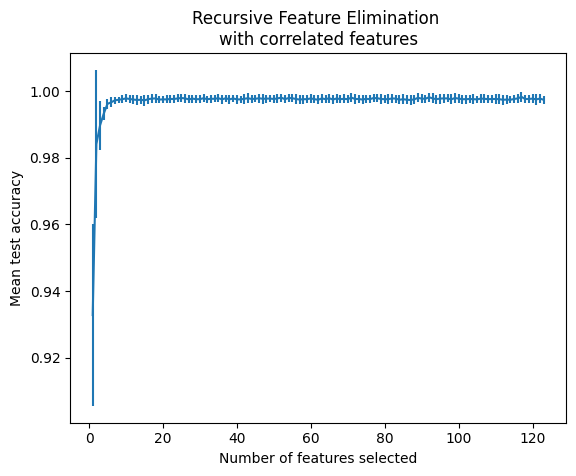

In [76]:
print(__doc__)

import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Create the RFE object and compute a cross-validated score.
# The "accuracy" scoring is proportional to the number of correct
# classifications
rfecv_DoS = RFECV(estimator=clf_DoS, step=1, cv=10, scoring='accuracy')
rfecv_DoS.fit(X_DoS_test, Y_DoS_test)

n_scores = len(rfecv_DoS.cv_results_["mean_test_score"])
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    range(1, n_scores + 1),
    rfecv_DoS.cv_results_["mean_test_score"],
    yerr=rfecv_DoS.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

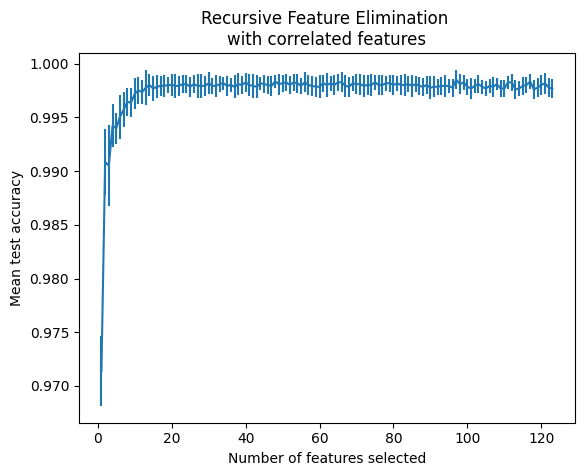

In [77]:
rfecv_Probe = RFECV(estimator=clf_Probe, step=1, cv=10, scoring='accuracy')
rfecv_Probe.fit(X_Probe_test, Y_Probe_test)
# Plot number of features VS. cross-validation scores
n_scores = len(rfecv_Probe.cv_results_["mean_test_score"])
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    range(1, n_scores + 1),
    rfecv_Probe.cv_results_["mean_test_score"],
    yerr=rfecv_Probe.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

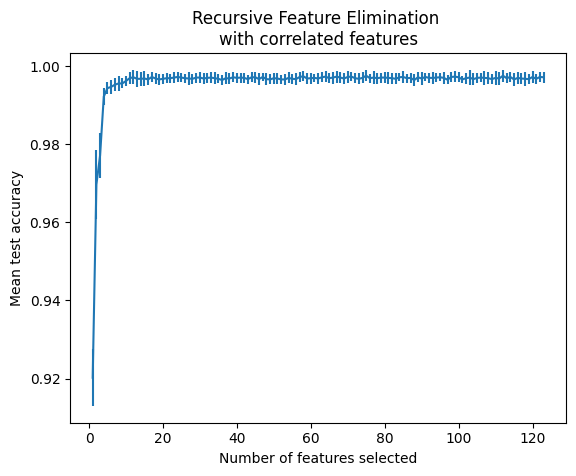

In [78]:
rfecv_R2L = RFECV(estimator=clf_R2L, step=1, cv=10, scoring='accuracy')
rfecv_R2L.fit(X_R2L_test, Y_R2L_test)
# Plot number of features VS. cross-validation scores
n_scores = len(rfecv_R2L.cv_results_["mean_test_score"])
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    range(1, n_scores + 1),
    rfecv_R2L.cv_results_["mean_test_score"],
    yerr=rfecv_R2L.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

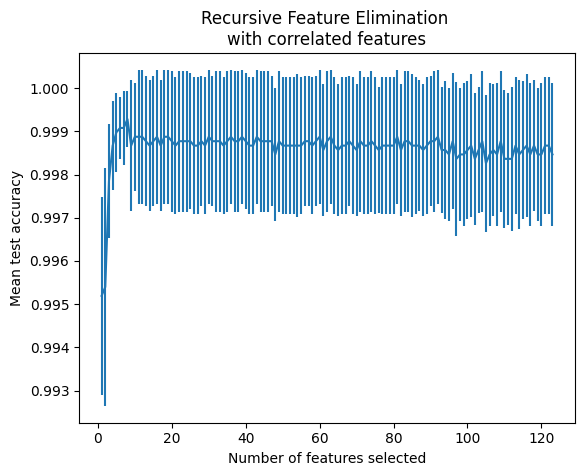

In [79]:
rfecv_U2R = RFECV(estimator=clf_U2R, step=1, cv=10, scoring='accuracy')
rfecv_U2R.fit(X_U2R_test, Y_U2R_test)
n_scores = len(rfecv_U2R.cv_results_["mean_test_score"])
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    range(1, n_scores + 1),
    rfecv_U2R.cv_results_["mean_test_score"],
    yerr=rfecv_U2R.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [80]:
# reduce test dataset to 13 features, use only features described in rfecolname_DoS etc.
X_DoS_test2=X_DoS_test[:,rfecolindex_DoS]
X_Probe_test2=X_Probe_test[:,rfecolindex_Probe]
X_R2L_test2=X_R2L_test[:,rfecolindex_R2L]
X_U2R_test2=X_U2R_test[:,rfecolindex_U2R]
X_U2R_test2.shape

(9778, 13)

In [81]:
Y_DoS_pred2=clf_rfeDoS.predict(X_DoS_test2)
# Create confusion matrix
pd.crosstab(Y_DoS_test, Y_DoS_pred2, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,1
Actual attacks,,
0,9363,348
1,1496,5963


In [82]:
Y_Probe_pred2=clf_rfeProbe.predict(X_Probe_test2)
# Create confusion matrix
pd.crosstab(Y_Probe_test, Y_Probe_pred2, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,2
Actual attacks,,
0,8644,1067
2,818,1603


In [83]:
Y_R2L_pred2=clf_rfeR2L.predict(X_R2L_test2)
# Create confusion matrix
pd.crosstab(Y_R2L_test, Y_R2L_pred2, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,3
Actual attacks,,
0,9707,4
3,2875,10


In [84]:
Y_U2R_pred2=clf_rfeU2R.predict(X_U2R_test2)
# Create confusion matrix
pd.crosstab(Y_U2R_test, Y_U2R_pred2, rownames=['Actual attacks'], colnames=['Predicted attacks'])

Predicted attacks,0,4
Actual attacks,,
0,9711,0
4,59,8


In [85]:
accuracy = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=10, scoring='precision')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=10, scoring='recall')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=10, scoring='f1')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))

Accuracy: 0.99808 (+/- 0.00173)
Precision: 0.99719 (+/- 0.00252)
Recall: 0.99839 (+/- 0.00201)
F-measure: 0.99779 (+/- 0.00199)


In [86]:
accuracy = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=10, scoring='precision_macro')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=10, scoring='recall_macro')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=10, scoring='f1_macro')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))

Accuracy: 0.99580 (+/- 0.00290)
Precision: 0.99308 (+/- 0.00652)
Recall: 0.99381 (+/- 0.00500)
F-measure: 0.99343 (+/- 0.00453)


In [87]:
accuracy = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=10, scoring='precision_macro')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=10, scoring='recall_macro')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=10, scoring='f1_macro')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))

Accuracy: 0.99301 (+/- 0.00375)
Precision: 0.99001 (+/- 0.00583)
Recall: 0.99023 (+/- 0.00657)
F-measure: 0.99011 (+/- 0.00530)


In [88]:
accuracy = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))
precision = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=10, scoring='precision_macro')
print("Precision: %0.5f (+/- %0.5f)" % (precision.mean(), precision.std() * 2))
recall = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=10, scoring='recall_macro')
print("Recall: %0.5f (+/- %0.5f)" % (recall.mean(), recall.std() * 2))
f = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=10, scoring='f1_macro')
print("F-measure: %0.5f (+/- %0.5f)" % (f.mean(), f.std() * 2))

Accuracy: 0.99816 (+/- 0.00220)
Precision: 0.93497 (+/- 0.09060)
Recall: 0.93168 (+/- 0.10875)
F-measure: 0.93165 (+/- 0.08622)


In [89]:
from sklearn.model_selection import StratifiedKFold
accuracy = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=StratifiedKFold(10), scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99808 (+/- 0.00173)


In [90]:
accuracy = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=StratifiedKFold(10), scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))


Accuracy: 0.99580 (+/- 0.00290)


In [91]:
accuracy = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=StratifiedKFold(10), scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99301 (+/- 0.00375)


In [92]:
accuracy = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=StratifiedKFold(10), scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99816 (+/- 0.00220)


CV DOS

In [93]:
accuracy = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=2, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99645 (+/- 0.00035)


In [94]:
accuracy = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=5, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99761 (+/- 0.00119)


In [95]:
accuracy = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99808 (+/- 0.00173)


In [96]:
accuracy = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=30, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99790 (+/- 0.00318)


In [97]:
accuracy = cross_val_score(clf_rfeDoS, X_DoS_test2, Y_DoS_test, cv=50, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99773 (+/- 0.00574)


CV Probe

In [98]:
accuracy = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=2, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99431 (+/- 0.00445)


In [99]:
accuracy = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=5, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99604 (+/- 0.00298)


In [100]:
accuracy = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99580 (+/- 0.00290)


In [101]:
accuracy = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=30, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99637 (+/- 0.00473)


In [102]:
accuracy = cross_val_score(clf_rfeProbe, X_Probe_test2, Y_Probe_test, cv=50, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99637 (+/- 0.00731)


# CV R2L

In [103]:
accuracy = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=2, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99095 (+/- 0.00191)


In [104]:
accuracy = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=5, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99270 (+/- 0.00217)


In [105]:
accuracy = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99301 (+/- 0.00375)


In [106]:
accuracy = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=30, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99325 (+/- 0.00977)


In [107]:
accuracy = cross_val_score(clf_rfeR2L, X_R2L_test2, Y_R2L_test, cv=50, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99365 (+/- 0.00940)


CV U2R

In [108]:
accuracy = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=2, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99744 (+/- 0.00061)


In [109]:
accuracy = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=5, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99826 (+/- 0.00104)


In [110]:
accuracy = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=10, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99816 (+/- 0.00220)


In [111]:
accuracy = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=30, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99826 (+/- 0.00378)


In [112]:
accuracy = cross_val_score(clf_rfeU2R, X_U2R_test2, Y_U2R_test, cv=50, scoring='accuracy')
print("Accuracy: %0.5f (+/- %0.5f)" % (accuracy.mean(), accuracy.std() * 2))

Accuracy: 0.99836 (+/- 0.00519)


ANN without ref

In [113]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout
from tensorflow.python.keras import regularizers

In [114]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/ANN1_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [115]:
import tensorflow as tf

In [116]:
# from tensorflow.keras.layers import BatchNormalization
# ann =Sequential()
# ann.add(Dense(units = 256,input_dim=123,activation = 'relu', kernel_regularizer=regularizers.l2(0.0001))),
# keras.layers.Dropout(0.3),
# keras.layers.BatchNormalization(),
# ann.add(Dense(units = 128,activation = 'relu', kernel_regularizer=regularizers.l2(0.0001))),
# keras.layers.Dropout(0.3),
# keras.layers.BatchNormalization(),
# ann.add(Dense(units = 64,activation = 'relu', kernel_regularizer=regularizers.l2(0.0001))),
# keras.layers.Dropout(0.3),
# keras.layers.BatchNormalization(),
# ann.add(Dense(units = 32,activation = 'relu', kernel_regularizer=regularizers.l2(0.0001))),
# keras.layers.Dropout(0.3),
# keras.layers.BatchNormalization(),
# ann.add(Dense(units = 1,activation = 'sigmoid'))

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras import regularizers

ann = Sequential([
    Input(shape=(123,)),   # 你的特征维度是 123

    Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.0001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.0001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu',
          kernel_regularizer=regularizers.l2(0.0001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.0001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')  # 二分类
])


In [117]:
ann.compile(optimizer= 'adam',loss='binary_crossentropy',metrics=['accuracy'])

In [118]:
from tensorflow.keras.callbacks import EarlyStopping
model=ann.fit(X_DoS, Y_DoS,batch_size = 250, validation_data=(X_DoS_test, Y_DoS_test),epochs =50,callbacks = [my_callbacks])

Epoch 1/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9614 - loss: 0.1521
Epoch 1: val_accuracy improved from None to 0.88626, saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9870 - loss: 0.0835 - val_accuracy: 0.8863 - val_loss: 0.5473
Epoch 2/50
446/454 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9978 - loss: 0.0458
Epoch 2: val_accuracy improved from 0.88626 to 0.89022, saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9980 - loss: 0.0437 - val_accuracy: 0.8902 - val_loss: 0.5445
Epoch 3/50
446/454 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9980 - loss: 0.0393
Epoch 3: val_accuracy improved from 0.89022 to 0.90419, saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5



Epoch 3: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9983 - loss: 0.0370 - val_accuracy: 0.9042 - val_loss: 0.5113
Epoch 4/50
449/454 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9984 - loss: 0.0328
Epoch 4: val_accuracy improved from 0.90419 to 0.92079, saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5



Epoch 4: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9985 - loss: 0.0313 - val_accuracy: 0.9208 - val_loss: 0.4699
Epoch 5/50
450/454 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9988 - loss: 0.0270
Epoch 5: val_accuracy did not improve from 0.92079
454/454 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9987 - loss: 0.0259 - val_accuracy: 0.9185 - val_loss: 0.4441
Epoch 6/50
449/454 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9988 - loss: 0.0229
Epoch 6: val_accuracy did not improve from 0.92079
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9987 - loss: 0.0219 - val_accuracy: 0.9043 - val_loss: 0.5501
Epoch 7/50
441/454 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0184
Epoch 7: val_accuracy improved from 0.92079 to 0.94089, saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5


...


Epoch 23: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9990 - loss: 0.0092 - val_accuracy: 0.9424 - val_loss: 0.3332
Epoch 24/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9993 - loss: 0.0076
Epoch 24: val_accuracy did not improve from 0.94240
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9992 - loss: 0.0079 - val_accuracy: 0.9084 - val_loss: 0.6268
Epoch 25/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0086
Epoch 25: val_accuracy did not improve from 0.94240
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9992 - loss: 0.0086 - val_accuracy: 0.9158 - val_loss: 0.4979
Epoch 26/50
443/454 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0082
Epoch 26: val_accuracy did not improve from 0.94240
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9989 - loss: 0.0088 - val_accuracy: 0.9231 - val_loss: 0.4364
Epoch 27/50
451/454 ━━━━━━━━━━━━


Epoch 27: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9991 - loss: 0.0085 - val_accuracy: 0.9442 - val_loss: 0.3038
Epoch 28/50
450/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0086
Epoch 28: val_accuracy improved from 0.94420 to 0.94473, saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5



Epoch 28: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9993 - loss: 0.0077 - val_accuracy: 0.9447 - val_loss: 0.2631
Epoch 29/50
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9991 - loss: 0.0081
Epoch 29: val_accuracy did not improve from 0.94473
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9991 - loss: 0.0085 - val_accuracy: 0.9299 - val_loss: 0.4204
Epoch 30/50
449/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0083
Epoch 30: val_accuracy did not improve from 0.94473
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9993 - loss: 0.0077 - val_accuracy: 0.9293 - val_loss: 0.3938
Epoch 31/50
441/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0076
Epoch 31: val_accuracy did not improve from 0.94473
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9992 - loss: 0.0077 - val_accuracy: 0.9236 - val_loss: 0.4289
Epoch 32/50
447/454 ━━━━━━━━━━━━


Epoch 37: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9993 - loss: 0.0077 - val_accuracy: 0.9567 - val_loss: 0.2203
Epoch 38/50
447/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9991 - loss: 0.0075
Epoch 38: val_accuracy did not improve from 0.95667
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9992 - loss: 0.0074 - val_accuracy: 0.9494 - val_loss: 0.3349
Epoch 39/50
437/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0067
Epoch 39: val_accuracy did not improve from 0.95667
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9993 - loss: 0.0072 - val_accuracy: 0.9525 - val_loss: 0.2720
Epoch 40/50
437/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0070
Epoch 40: val_accuracy improved from 0.95667 to 0.96104, saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5



Epoch 40: finished saving model to /content/drive/MyDrive/check/ANN1_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9994 - loss: 0.0075 - val_accuracy: 0.9610 - val_loss: 0.2312
Epoch 41/50
444/454 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0095
Epoch 41: val_accuracy did not improve from 0.96104
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9993 - loss: 0.0081 - val_accuracy: 0.9425 - val_loss: 0.3764
Epoch 42/50
447/454 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.0072
Epoch 42: val_accuracy did not improve from 0.96104
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9992 - loss: 0.0076 - val_accuracy: 0.9312 - val_loss: 0.4331
Epoch 43/50
447/454 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9994 - loss: 0.0072
Epoch 43: val_accuracy did not improve from 0.96104
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9993 - loss: 0.0075 - val_accuracy: 0.9471 - val_loss: 0.2836
Epoch 44/50
452/454 ━━━━━━━━━━━━

In [119]:
y_pred = ann.predict(X_DoS_test)

537/537 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [120]:
y_pred

array([[9.9982917e-01],
       [2.7793367e-05],
       [8.1351202e-05],
       ...,
       [6.8430963e-05],
       [9.9847108e-01],
       [1.4307235e-06]], dtype=float32)

In [121]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [122]:
y_pred = np.array(y_pred1)
y_pred

array([1, 0, 0, ..., 0, 1, 0])

In [123]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      9711
           1       0.99      0.85      0.91      7459

    accuracy                           0.93     17170
   macro avg       0.94      0.92      0.93     17170
weighted avg       0.94      0.93      0.93     17170



ANN with Ref

In [124]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/ANN1ref_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [125]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, LearningRateScheduler

In [126]:
X_rfeDoS.shape

(113269, 13)

In [127]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# Create a Sequential model
ann = Sequential()

# Add layers to the model with the specified configurations
ann.add(Dense(units=256, input_dim=13, activation='relu', kernel_regularizer=l2(0.001)))
ann.add(Dropout(0.3))
ann.add(BatchNormalization())
# ann.add(Dense(units=128, activation='relu', kernel_regularizer=l2(0.001)))
# ann.add(Dropout(0.3))
# ann.add(BatchNormalization())
ann.add(Dense(units=64, activation='relu', kernel_regularizer=l2(0.001)))
ann.add(Dropout(0.3))
ann.add(BatchNormalization())
# ann.add(Dense(units=32, activation='relu', kernel_regularizer=l2(0.001)))
# ann.add(Dropout(0.3))
ann.add(BatchNormalization())
ann.add(Dense(units=1, activation='sigmoid'))

# Your model is now defined with the desired layers and configurations.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [128]:
ann.compile(optimizer= 'adam',loss='binary_crossentropy',metrics=['accuracy'])

In [129]:
from tensorflow.keras.callbacks import EarlyStopping
model=ann.fit(X_rfeDoS, Y_DoS,batch_size = 64, validation_data=(X_DoS_test2, Y_DoS_test),epochs =50,callbacks = [my_callbacks])

Epoch 1/50
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9832 - loss: 0.1219
Epoch 1: val_accuracy improved from None to 0.86593, saving model to /content/drive/MyDrive/check/ANN1ref_intrusion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/check/ANN1ref_intrusion.h5
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9921 - loss: 0.0713 - val_accuracy: 0.8659 - val_loss: 0.6965
Epoch 2/50
1760/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9956 - loss: 0.0293
Epoch 2: val_accuracy improved from 0.86593 to 0.89476, saving model to /content/drive/MyDrive/check/ANN1ref_intrusion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/check/ANN1ref_intrusion.h5
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9957 - loss: 0.0270 - val_accuracy: 0.8948 - val_loss: 0.7884
Epoch 3/50
1755/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9963 - loss: 0.0226
Epoch 3: val_accuracy did not improve from 0.89476
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9964 - loss: 0.0219 - val_accuracy: 0.8717 - val_loss: 0.8870
Epoch 4/50
1764/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9964 - loss: 0.0218
Epoch 4: val_accuracy did not improve from 0.89476
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9961 - loss: 0.0219 - val_accuracy: 0.8793 - val_loss: 0.7094
Epoch 5/50
1764/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9963 - loss: 0.0203
Epoch 5: val_accuracy improved from 0.89476 to 0.91019, saving model to /content/drive/MyDrive/check/ANN1ref_intrusion.h5



Epoch 5: finished saving model to /content/drive/MyDrive/check/ANN1ref_intrusion.h5
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9965 - loss: 0.0203 - val_accuracy: 0.9102 - val_loss: 0.6225
Epoch 6/50
1751/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9961 - loss: 0.0215
Epoch 6: val_accuracy did not improve from 0.91019
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9964 - loss: 0.0205 - val_accuracy: 0.8808 - val_loss: 0.8657
Epoch 7/50
1761/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9963 - loss: 0.0197
Epoch 7: val_accuracy did not improve from 0.91019
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9967 - loss: 0.0191 - val_accuracy: 0.8639 - val_loss: 0.8132
Epoch 8/50
1760/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9967 - loss: 0.0182
Epoch 8: val_accuracy did not improve from 0.91019
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9967 - loss: 0.0183 - val_accuracy: 0.9016 - val_loss: 0.7825
Epoch 9/50
1766/1770 ━


Epoch 22: finished saving model to /content/drive/MyDrive/check/ANN1ref_intrusion.h5
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9969 - loss: 0.0163 - val_accuracy: 0.9109 - val_loss: 0.8666
Epoch 23/50
1758/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9966 - loss: 0.0164
Epoch 23: val_accuracy did not improve from 0.91089
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9964 - loss: 0.0166 - val_accuracy: 0.9010 - val_loss: 0.7903
Epoch 24/50
1755/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9970 - loss: 0.0156
Epoch 24: val_accuracy did not improve from 0.91089
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9968 - loss: 0.0163 - val_accuracy: 0.8937 - val_loss: 0.8012
Epoch 25/50
1753/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9965 - loss: 0.0183
Epoch 25: val_accuracy did not improve from 0.91089
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9965 - loss: 0.0178 - val_accuracy: 0.9015 - val_loss: 0.7200
Epoch 26/50
175

In [130]:
y_pred = ann.predict(X_DoS_test2)

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [131]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [132]:
y_pred = np.array(y_pred1)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [133]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.99      0.90      9711
           1       0.98      0.71      0.83      7459

    accuracy                           0.87     17170
   macro avg       0.90      0.85      0.86     17170
weighted avg       0.89      0.87      0.86     17170



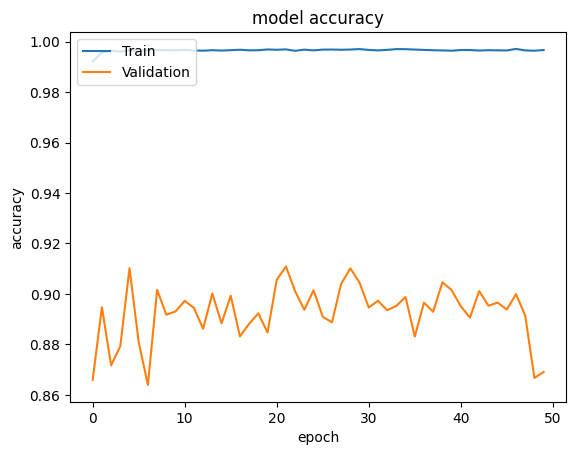

In [134]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(model.history['accuracy'])
plt.plot(model.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('acc_withoutref.png')
plt.show()


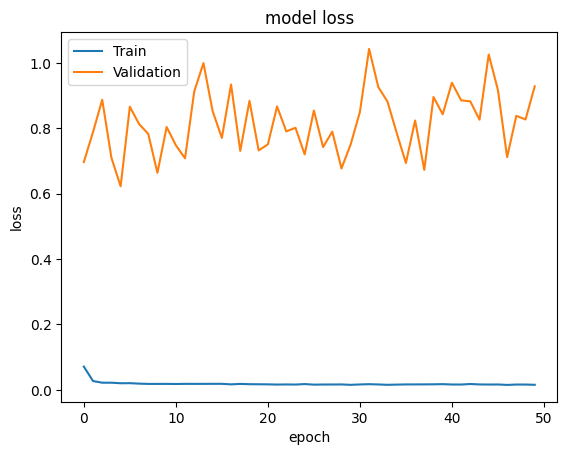

In [135]:
plt.plot(model.history['loss'])
plt.plot(model.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss_withoutref.png')
plt.show()

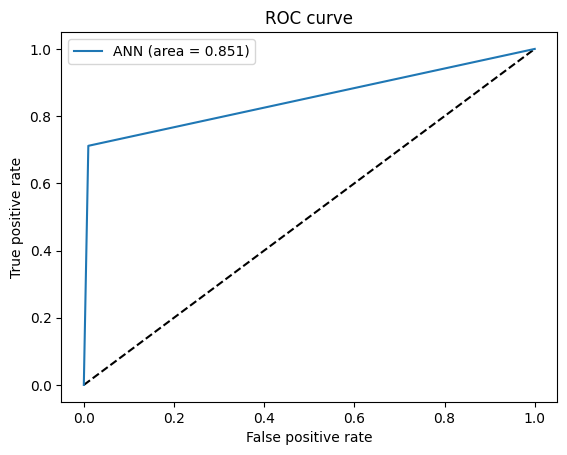

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM
from keras.layers import Conv1D, MaxPooling1D
fpr, tpr, thresholds = roc_curve(Y_DoS_test, y_pred)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='ANN (area = {:.3f})'.format(auc(fpr, tpr)))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

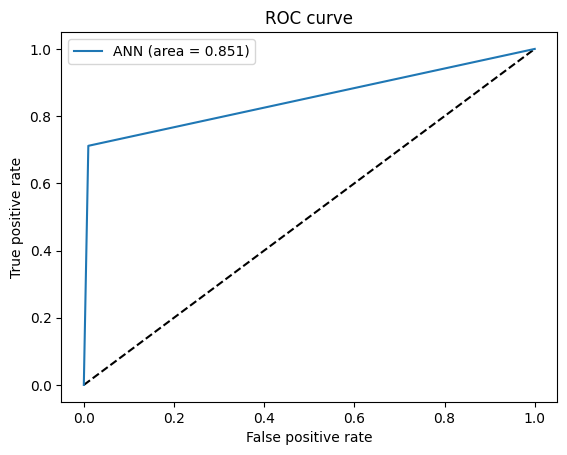

In [137]:
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='ANN (area = {:.3f})'.format(auc(fpr, tpr)))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

DS-LSTM-CNN Without ref

In [138]:
X_DoS = np.array(X_DoS)
X_DoS_test = np.array(X_DoS_test)
#cnn-input
X_DoS = np.reshape(X_DoS, (X_DoS.shape[0], X_DoS.shape[1], 1))
X_DoS_test = np.reshape(X_DoS_test, (X_DoS_test.shape[0], X_DoS_test.shape[1], 1))
#lstm-input

In [139]:
Y_DoS = np.array(Y_DoS)

In [140]:
Y_DoS_test = np.array(Y_DoS_test)

In [141]:
import numpy as np
from keras.models import Sequential
from keras.layers import SeparableConv1D, MaxPooling1D, LSTM, Dense, Dropout
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, LearningRateScheduler

In [142]:
# Define a learning rate schedule
initial_learning_rate = 0.001
def lr_schedule(epoch):
    return initial_learning_rate * (0.1 ** (epoch // 10))

In [143]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# Define early stopping and learning rate scheduler callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = LearningRateScheduler(lr_schedule)

# Define the rest of your callbacks
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/cnnlstmk_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max'),
    early_stopping,
    lr_scheduler
]

In [144]:
import time
model = Sequential()

# ===== DS-CNN Block 1 =====
model.add(SeparableConv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    input_shape=(X_DoS.shape[1], 1),
    activation='relu',
    depthwise_regularizer=l2(0.01),
    pointwise_regularizer=l2(0.01)
))

model.add(SeparableConv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation='relu',
    depthwise_regularizer=l2(0.01),
    pointwise_regularizer=l2(0.01)
))

model.add(MaxPooling1D(pool_size=2))

# ===== DS-CNN Block 2 =====
model.add(SeparableConv1D(
    filters=128,
    kernel_size=3,
    padding="same",
    activation='relu',
    depthwise_regularizer=l2(0.001),
    pointwise_regularizer=l2(0.001)
))

model.add(SeparableConv1D(
    filters=128,
    kernel_size=3,
    padding="same",
    activation='relu',
    depthwise_regularizer=l2(0.001),
    pointwise_regularizer=l2(0.001)
))

model.add(MaxPooling1D(pool_size=2))

# ===== Batch Normalization（保持不变）=====
model.add(BatchNormalization())

# ===== LSTM（保持不变）=====
model.add(LSTM(
    units=100,
    return_sequences=False,
    dropout=0.1,
    kernel_regularizer=l2(0.01)
))

model.add(Dropout(0.5))

# ===== Output（保持不变）=====
model.add(Dense(
    units=1,
    activation='sigmoid',
    kernel_regularizer=l2(0.01)
))

# Compile（保持不变）
opt = Adam(learning_rate=initial_learning_rate)
model.compile(
    loss='binary_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

# # Train（保持不变）
# history = model.fit(
#     X_DoS, Y_DoS,
#     epochs=50,
#     batch_size=64,
#     validation_data=(X_DoS_test, Y_DoS_test),
#     callbacks=my_callbacks
# )
start_time = time.time()

history = model.fit(
    X_DoS, Y_DoS,
    epochs=50,
    batch_size=64,
    validation_data=(X_DoS_test, Y_DoS_test),
    callbacks=my_callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"训练时间: {training_time:.2f} 秒")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/50
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8779 - loss: 0.6471
Epoch 1: val_accuracy improved from None to 0.91648, saving model to /content/drive/MyDrive/check/cnnlstmk_intrusion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/check/cnnlstmk_intrusion.h5
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.9473 - loss: 0.3020 - val_accuracy: 0.9165 - val_loss: 0.3642 - learning_rate: 0.0010
Epoch 2/50
1765/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9907 - loss: 0.1125
Epoch 2: val_accuracy did not improve from 0.91648
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9919 - loss: 0.1018 - val_accuracy: 0.4937 - val_loss: 1.9260 - learning_rate: 0.0010
Epoch 3/50
1768/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9935 - loss: 0.0820
Epoch 3: val_accuracy did not improve from 0.91648
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9940 - loss: 0.0763 - val_accuracy: 0.5716 - val_loss: 1.9764 - learning_rate: 0.0010
Epoch 4/50
1769/1770 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9950 - loss: 0.0667
Epoch 4: val_accuracy did not improve from 0.91648
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.

In [145]:
# ===== 参数量统计 =====
print("模型参数量：")
model.summary()

ds_total_params = model.count_params()
print(f"Total Params: {ds_total_params}")

模型参数量：


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d                │ (None, 123, 64)        │           131 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 123, 64)        │         4,352 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_2              │ (None, 61, 128)        │         8,512 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_3              │ (None, 61, 128)        │        16,896 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,802 (1.40 MB)

 Trainable params: 121,848 (475.97 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 243,698 (951.95 KB)

Total Params: 122104


In [146]:
# ===== 推理时间测试 =====
import numpy as np
import time

# 取一部分测试数据（避免太慢）
sample_data = X_DoS_test[:1000]

start_time = time.time()

predictions = model.predict(sample_data)

end_time = time.time()
inference_time = end_time - start_time

print(f"推理时间（1000条数据）: {inference_time:.6f} 秒")
print(f"平均每条推理时间: {inference_time / len(sample_data):.8f} 秒")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
推理时间（1000条数据）: 1.978430 秒
平均每条推理时间: 0.00197843 秒


In [147]:
dscnn_params = ds_total_params
dscnn_train_time = training_time
dscnn_infer_time = inference_time

In [148]:
from keras.models import load_model
model = load_model('/content/drive/MyDrive/check/cnnlstmk_intrusion.h5')

In [149]:
y_pred = model.predict(X_DoS_test)

537/537 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [150]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [151]:
y_pred = np.array(y_pred1)
y_pred

array([1, 0, 0, ..., 0, 1, 0])

In [152]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      9711
           1       0.91      0.89      0.90      7459

    accuracy                           0.92     17170
   macro avg       0.92      0.91      0.91     17170
weighted avg       0.92      0.92      0.92     17170



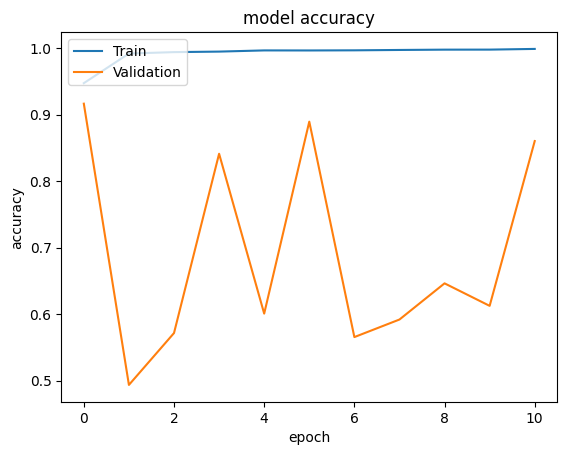

In [153]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('acc_withoutref.png')
plt.show()

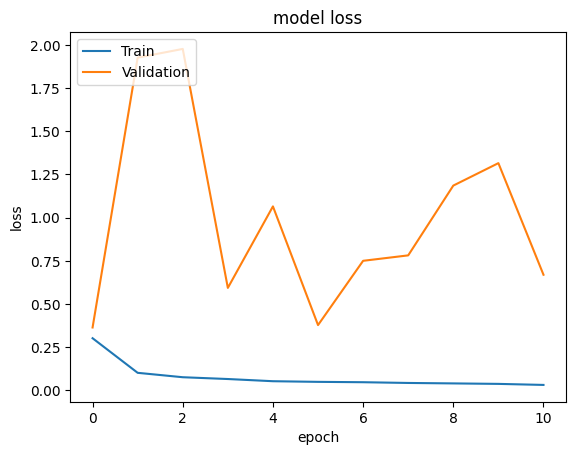

In [154]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss_withoutref.png')
plt.show()

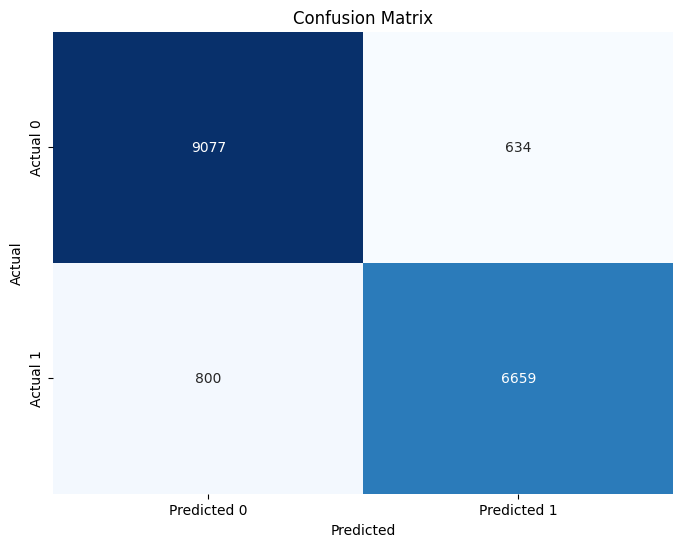

In [155]:
from matplotlib import pylab
from pylab import *
cm = confusion_matrix(Y_DoS_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('heatmap_withoutref.png')
plt.show()

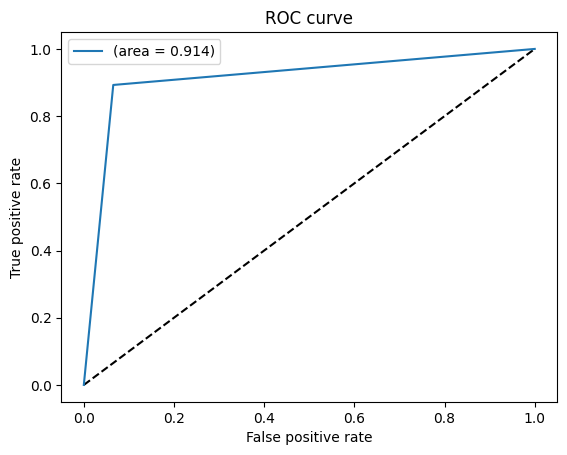

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM
from keras.layers import Conv1D, MaxPooling1D
fpr, tpr, thresholds = roc_curve(Y_DoS_test, y_pred)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='(area = {:.3f})'.format(auc(fpr, tpr)))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.savefig('roc_withoutref.png')
plt.show()

DS-LSTM-CNN With ref

In [157]:
X_rfeDoS.shape

(113269, 13)

In [158]:
X_rfeDoS = np.array(X_rfeDoS)
X_DoS_test2 = np.array(X_DoS_test2)
#cnn-input
X_rfeDoS = np.reshape(X_rfeDoS, (X_rfeDoS.shape[0], X_rfeDoS.shape[1], 1))
X_DoS_test2 = np.reshape(X_DoS_test2, (X_DoS_test2.shape[0], X_DoS_test2.shape[1], 1))

In [159]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# Define a learning rate schedule
initial_learning_rate = 0.001
def lr_schedule(epoch):
    return initial_learning_rate * (0.1 ** (epoch // 10))

In [160]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# Define early stopping and learning rate scheduler callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = LearningRateScheduler(lr_schedule)

# Define the rest of your callbacks
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max'),
    early_stopping,
    lr_scheduler
]

In [161]:
from keras.models import Sequential
from keras.layers import SeparableConv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam

# Define a learning rate
initial_learning_rate = 0.001

# Initialize the model
model = Sequential()

input_shape = (X_rfeDoS.shape[1], 1)

# ===== DS-CNN Block 1 =====
model.add(SeparableConv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    input_shape=input_shape,
    activation='relu',
    depthwise_initializer='he_normal',
    pointwise_initializer='he_normal'
))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# ===== DS-CNN Block 2 =====
model.add(SeparableConv1D(
    filters=128,
    kernel_size=3,
    padding="same",
    activation='relu',
    depthwise_initializer='he_normal',
    pointwise_initializer='he_normal'
))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# ===== DS-CNN Block 3 =====
model.add(SeparableConv1D(
    filters=256,
    kernel_size=3,
    padding="same",
    activation='relu',
    depthwise_initializer='he_normal',
    pointwise_initializer='he_normal'
))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.4))

# ===== LSTM Layer (unchanged) =====
model.add(LSTM(
    units=150,
    dropout=0.2,
    return_sequences=False
))

# ===== Output Layer =====
model.add(Dense(
    units=1,
    activation='sigmoid',
    kernel_regularizer=l2(0.01)
))

# Compile the model
opt = Adam(learning_rate=initial_learning_rate)
model.compile(
    loss='binary_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_rfeDoS, Y_DoS,
    epochs=100,
    batch_size=250,
    validation_data=(X_DoS_test2, Y_DoS_test),
    callbacks=my_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9451 - loss: 0.1612
Epoch 1: val_accuracy improved from None to 0.81672, saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9756 - loss: 0.0794 - val_accuracy: 0.8167 - val_loss: 0.6339 - learning_rate: 0.0010
Epoch 2/100
451/454 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9910 - loss: 0.0322
Epoch 2: val_accuracy improved from 0.81672 to 0.84752, saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9923 - loss: 0.0290 - val_accuracy: 0.8475 - val_loss: 0.8139 - learning_rate: 0.0010
Epoch 3/100
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9938 - loss: 0.0241
Epoch 3: val_accuracy improved from 0.84752 to 0.84991, saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5



Epoch 3: finished saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9940 - loss: 0.0235 - val_accuracy: 0.8499 - val_loss: 0.8659 - learning_rate: 0.0010
Epoch 4/100
450/454 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9948 - loss: 0.0216
Epoch 4: val_accuracy did not improve from 0.84991
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9951 - loss: 0.0202 - val_accuracy: 0.8492 - val_loss: 0.9077 - learning_rate: 0.0010
Epoch 5/100
450/454 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9959 - loss: 0.0182
Epoch 5: val_accuracy improved from 0.84991 to 0.85009, saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5



Epoch 5: finished saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9962 - loss: 0.0175 - val_accuracy: 0.8501 - val_loss: 0.8970 - learning_rate: 0.0010
Epoch 6/100
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9965 - loss: 0.0165
Epoch 6: val_accuracy did not improve from 0.85009
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9967 - loss: 0.0162 - val_accuracy: 0.8501 - val_loss: 0.8964 - learning_rate: 0.0010
Epoch 7/100
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9971 - loss: 0.0152
Epoch 7: val_accuracy improved from 0.85009 to 0.85300, saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5



Epoch 7: finished saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9970 - loss: 0.0153 - val_accuracy: 0.8530 - val_loss: 0.8919 - learning_rate: 0.0010
Epoch 8/100
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9973 - loss: 0.0143
Epoch 8: val_accuracy improved from 0.85300 to 0.85393, saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5



Epoch 8: finished saving model to /content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9973 - loss: 0.0148 - val_accuracy: 0.8539 - val_loss: 0.8349 - learning_rate: 0.0010
Epoch 9/100
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9974 - loss: 0.0141
Epoch 9: val_accuracy did not improve from 0.85393
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9975 - loss: 0.0140 - val_accuracy: 0.8506 - val_loss: 0.8771 - learning_rate: 0.0010
Epoch 10/100
451/454 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9976 - loss: 0.0134
Epoch 10: val_accuracy did not improve from 0.85393
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9976 - loss: 0.0136 - val_accuracy: 0.8510 - val_loss: 0.9069 - learning_rate: 0.0010
Epoch 11/100
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9978 - loss: 0.0132
Epoch 11: val_accuracy did not improve from 0.85393
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9977 - lo

In [ ]:
from keras.models import load_model
model = load_model('/content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5')

In [ ]:
y_pred = model.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('acc_withref.png')
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss_withref.png')
plt.show()

In [ ]:
from matplotlib import pylab
from pylab import *
cm = confusion_matrix(Y_DoS_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('heatmap_withref.png')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM
from keras.layers import Conv1D, MaxPooling1D
fpr, tpr, thresholds = roc_curve(Y_DoS_test, y_pred)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='(area = {:.3f})'.format(auc(fpr, tpr)))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.savefig('roc_withref.png')

plt.show()

LSTM-CNN Without ref

In [ ]:
X_DoS = np.array(X_DoS)
X_DoS_test = np.array(X_DoS_test)
#cnn-input
X_DoS = np.reshape(X_DoS, (X_DoS.shape[0], X_DoS.shape[1], 1))
X_DoS_test = np.reshape(X_DoS_test, (X_DoS_test.shape[0], X_DoS_test.shape[1], 1))
#lstm-input

In [ ]:
Y_DoS = np.array(Y_DoS)

In [ ]:
Y_DoS_test = np.array(Y_DoS_test)

In [ ]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, LearningRateScheduler

In [ ]:
# Define a learning rate schedule
initial_learning_rate = 0.001
def lr_schedule(epoch):
    return initial_learning_rate * (0.1 ** (epoch // 10))

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# Define early stopping and learning rate scheduler callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = LearningRateScheduler(lr_schedule)

# Define the rest of your callbacks
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/cnnlstmk_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max'),
    early_stopping,
    lr_scheduler
]

In [ ]:
# from keras.callbacks import ModelCheckpoint
# my_callbacks = [
#     ModelCheckpoint(filepath='/content/drive/MyDrive/check/cnnlstmk_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
# ]

In [ ]:
# from keras.models import Sequential
# from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
# from keras.regularizers import l2

# model = Sequential() # initializing model

# # cnn-lstm
# model.add(Conv1D(64, 3, padding="same", input_shape=(X_DoS.shape[1], 1), activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Conv1D(64, 3, padding="same", activation='relu', kernel_regularizer=l2(0.01)))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Conv1D(128, 3, padding="same", activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Conv1D(128, 3, padding="same", activation='relu', kernel_regularizer=l2(0.01)))
# model.add(MaxPooling1D(pool_size=2))
# model.add(LSTM(units=100, return_sequences=False, dropout=0.1, kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.5))  # Add dropout to reduce overfitting
# model.add(Dense(units=1, activation='sigmoid', kernel_regularizer=l2(0.01)))

# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# history = model.fit(X_DoS, Y_DoS, epochs=50, batch_size=64, validation_data=(X_DoS_test, Y_DoS_test), callbacks=[my_callbacks])

import time
# Initialize the model
model = Sequential()

# Add Convolutional and MaxPooling Layers with L2 Regularization
model.add(Conv1D(64, 3, padding="same", input_shape=(X_DoS.shape[1], 1), activation='relu', kernel_regularizer=l2(0.01)))
model.add(Conv1D(64, 3, padding="same", activation='relu', kernel_regularizer=l2(0.01)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, 3, padding="same", activation='relu', kernel_regularizer=l2(0.001)))
model.add(Conv1D(128, 3, padding="same", activation='relu', kernel_regularizer=l2(0.001)))
model.add(MaxPooling1D(pool_size=2))

# Add Batch Normalization
model.add(BatchNormalization())

# Add LSTM layer with L2 Regularization
model.add(LSTM(units=100, return_sequences=False, dropout=0.1, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))  # Add dropout to reduce overfitting

# Add Dense layer with L2 Regularization
model.add(Dense(units=1, activation='sigmoid', kernel_regularizer=l2(0.01)))

# Compile the model with a custom learning rate schedule
opt = Adam(learning_rate=initial_learning_rate)
model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# Train the model
start_time = time.time()
history = model.fit(X_DoS, Y_DoS, epochs=50, batch_size=64, validation_data=(X_DoS_test, Y_DoS_test), callbacks=my_callbacks)
end_time = time.time()
training_time = end_time - start_time

print(f"训练时间: {training_time:.2f} 秒")

In [179]:
# ===== 参数量统计 =====
print("模型参数量：")
model.summary()

total_params = model.count_params()
print(f"Total Params: {total_params}")

模型参数量：


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 123, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 123, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,905 (2.04 MB)

 Trainable params: 178,549 (697.46 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 357,100 (1.36 MB)

Total Params: 178805


In [ ]:
# ===== 推理时间测试 =====
import numpy as np
import time

# 取一部分测试数据（避免太慢）
sample_data = X_DoS_test[:1000]

start_time = time.time()

predictions = model.predict(sample_data)

end_time = time.time()
inference_time = end_time - start_time

print(f"推理时间（1000条数据）: {inference_time:.6f} 秒")
print(f"平均每条推理时间: {inference_time / len(sample_data):.8f} 秒")

In [ ]:
cnn_params = total_params
cnn_train_time = training_time
cnn_infer_time = inference_time

In [ ]:
from keras.models import load_model
model = load_model('/content/drive/MyDrive/check/cnnlstmk_intrusion.h5')

In [183]:
y_pred = model.predict(X_DoS_test)

537/537 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [184]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [185]:
y_pred = np.array(y_pred1)
y_pred

array([1, 0, 0, ..., 0, 1, 0])

In [186]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      9711
           1       0.92      0.91      0.92      7459

    accuracy                           0.93     17170
   macro avg       0.93      0.93      0.93     17170
weighted avg       0.93      0.93      0.93     17170



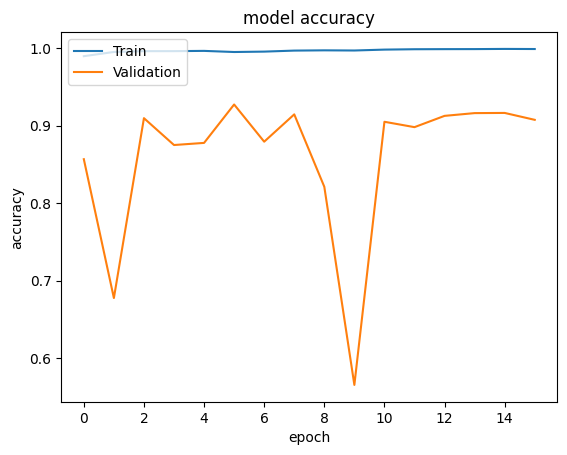

In [187]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('acc_withoutref.png')
plt.show()


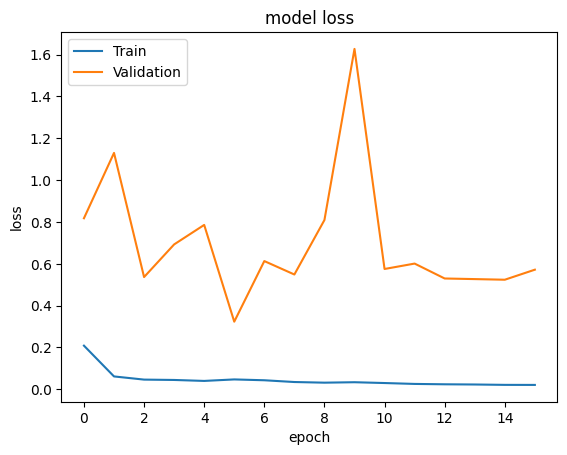

In [188]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss_withoutref.png')
plt.show()

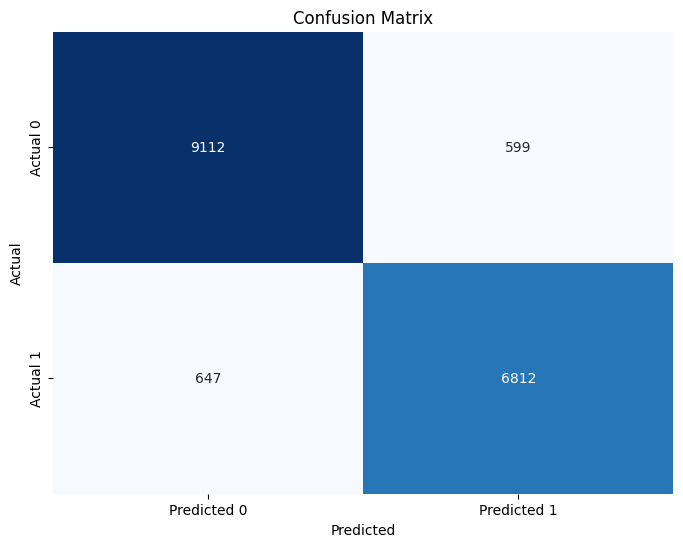

In [189]:
from matplotlib import pylab
from pylab import *
cm = confusion_matrix(Y_DoS_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('heatmap_withoutref.png')
plt.show()

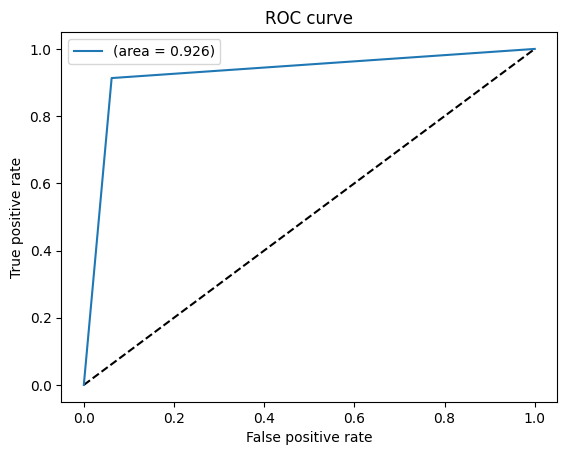

In [190]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM
from keras.layers import Conv1D, MaxPooling1D
fpr, tpr, thresholds = roc_curve(Y_DoS_test, y_pred)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='(area = {:.3f})'.format(auc(fpr, tpr)))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.savefig('roc_withoutref.png')
plt.show()

In [191]:
import pandas as pd

# 构建数据
data = {
    "模型": ["CNN-LSTM", "DS-CNN-LSTM"],
    "参数量": [cnn_params, dscnn_params],
    "推理时间(s)": [cnn_infer_time, dscnn_infer_time]
}

df = pd.DataFrame(data)

# ===== 增加对比指标 =====
param_reduction = (cnn_params - dscnn_params) / cnn_params * 100

df["参数变化"] = ["基准模型", f"↓ {param_reduction:.2f}%"]

df["推理效率"] = [
    "基准",
    "↑" if dscnn_infer_time < cnn_infer_time else "↓"
]

# ===== 格式优化 =====
df["参数量"] = df["参数量"].apply(lambda x: f"{x:,}")
df["推理时间(s)"] = df["推理时间(s)"].apply(lambda x: f"{x:.4f}")

df.style.set_properties(**{
    'text-align': 'center'
})

,模型,参数量,推理时间(s),参数变化,推理效率
0,CNN-LSTM,"178,805",0.6258,基准模型,基准
1,DS-CNN-LSTM,"122,104",1.9784,↓ 31.71%,↓


LSTM-CNN With ref

In [192]:
X_rfeDoS.shape

(113269, 13, 1)

In [193]:
X_rfeDoS = np.array(X_rfeDoS)
X_DoS_test2 = np.array(X_DoS_test2)
#cnn-input
X_rfeDoS = np.reshape(X_rfeDoS, (X_rfeDoS.shape[0], X_rfeDoS.shape[1], 1))
X_DoS_test2 = np.reshape(X_DoS_test2, (X_DoS_test2.shape[0], X_DoS_test2.shape[1], 1))

In [194]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# Define a learning rate schedule
initial_learning_rate = 0.001
def lr_schedule(epoch):
    return initial_learning_rate * (0.1 ** (epoch // 10))


In [195]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# Define early stopping and learning rate scheduler callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = LearningRateScheduler(lr_schedule)

# Define the rest of your callbacks
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/cnnlstmkref_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max'),
    early_stopping,
    lr_scheduler
]

In [196]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Define a learning rate schedule
initial_learning_rate = 0.001

# Initialize the model
model = Sequential()

input_shape = (X_rfeDoS.shape[1], 1)

# Convolutional layers
model.add(Conv1D(64, 3, padding="same", input_shape=input_shape, activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv1D(128, 3, padding="same", activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Conv1D(256, 3, padding="same", activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.4))

# LSTM layer
# model.add(GRU(units=150, return_sequences=False, dropout=0.25, recurrent_dropout=0.25))
model.add(LSTM(units=150, dropout=0.2, return_sequences=False))

# Dense layer
model.add(Dense(units=1, activation='sigmoid', kernel_regularizer=l2(0.01)))

# Compile the model
opt = Adam(learning_rate=initial_learning_rate)
model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# Callbacks
# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
# callbacks_list = [early_stopping, reduce_lr]

# Train the model
history = model.fit(X_rfeDoS, Y_DoS, epochs=100, batch_size=250, validation_data=(X_DoS_test2, Y_DoS_test), callbacks=my_callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9736 - loss: 0.0960
Epoch 1: val_accuracy improved from None to 0.89592, saving model to /content/drive/MyDrive/check/cnnlstmkref_intrusion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/check/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9883 - loss: 0.0471 - val_accuracy: 0.8959 - val_loss: 0.5154 - learning_rate: 0.0010
Epoch 2/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9953 - loss: 0.0203
Epoch 2: val_accuracy improved from 0.89592 to 0.90594, saving model to /content/drive/MyDrive/check/cnnlstmkref_intrusion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/check/cnnlstmkref_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9958 - loss: 0.0191 - val_accuracy: 0.9059 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 3/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9969 - loss: 0.0156
Epoch 3: val_accuracy did not improve from 0.90594
454/454 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9970 - loss: 0.0156 - val_accuracy: 0.9035 - val_loss: 0.4708 - learning_rate: 0.0010
Epoch 4/100
450/454 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9972 - loss: 0.0144
Epoch 4: val_accuracy did not improve from 0.90594
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9973 - loss: 0.0141 - val_accuracy: 0.9003 - val_loss: 0.5417 - learning_rate: 0.0010
Epoch 5/100
450/454 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9978 - loss: 0.0129
Epoch 5: val_accuracy did not improve from 0.90594
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9978 - loss:

In [ ]:
from keras.models import load_model
model = load_model('/content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5')

In [ ]:
y_pred = model.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('acc_withref.png')
plt.show()


In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss_withref.png')
plt.show()

In [ ]:
from matplotlib import pylab
from pylab import *
cm = confusion_matrix(Y_DoS_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('heatmap_withref.png')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM
from keras.layers import Conv1D, MaxPooling1D
fpr, tpr, thresholds = roc_curve(Y_DoS_test, y_pred)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='(area = {:.3f})'.format(auc(fpr, tpr)))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.savefig('roc_withref.png')

plt.show()

Bi-LSTM without ref

In [ ]:
X_DoS = np.array(X_DoS)
X_DoS_test = np.array(X_DoS_test)
#cnn-input
X_DoS = np.reshape(X_DoS, (X_DoS.shape[0], X_DoS.shape[1], 1))
X_DoS_test = np.reshape(X_DoS_test, (X_DoS_test.shape[0], X_DoS_test.shape[1], 1))
#lstm-input

In [ ]:
Y_DoS = np.array(Y_DoS)

In [ ]:
Y_DoS_test = np.array(Y_DoS_test)

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/bilstmk_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import Callback

# Initialize the model
model = Sequential()

# BiLSTM layer
model.add(Bidirectional(LSTM(units=100, dropout=0.2, return_sequences=False), input_shape=(X_DoS.shape[1], 1)))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define your X_DoS, Y_DoS, X_DoS_test, Y_DoS_test data
# and your custom callback my_callbacks if needed

# Train the model
model.fit(X_DoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test, Y_DoS_test), callbacks=[my_callbacks])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8686 - loss: 0.3096
Epoch 1: val_accuracy improved from None to 0.80996, saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9213 - loss: 0.1919 - val_accuracy: 0.8100 - val_loss: 0.5183
Epoch 2/50
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9593 - loss: 0.0941
Epoch 2: val_accuracy improved from 0.80996 to 0.82638, saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9622 - loss: 0.0850 - val_accuracy: 0.8264 - val_loss: 0.4695
Epoch 3/50
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9717 - loss: 0.0640
Epoch 3: val_accuracy did not improve from 0.82638
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9712 - loss: 0.0642 - val_accuracy: 0.8220 - val_loss: 0.5857
Epoch 4/50
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9737 - loss: 0.0571
Epoch 4: val_accuracy improved from 0.82638 to 0.86645, saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5



Epoch 4: finished saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9762 - loss: 0.0509 - val_accuracy: 0.8665 - val_loss: 0.4688
Epoch 5/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9792 - loss: 0.0423
Epoch 5: val_accuracy did not improve from 0.86645
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9796 - loss: 0.0413 - val_accuracy: 0.8616 - val_loss: 0.5418
Epoch 6/50
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9798 - loss: 0.0405
Epoch 6: val_accuracy improved from 0.86645 to 0.87158, saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5



Epoch 6: finished saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9798 - loss: 0.0397 - val_accuracy: 0.8716 - val_loss: 0.5508
Epoch 7/50
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9804 - loss: 0.0370
Epoch 7: val_accuracy did not improve from 0.87158
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9808 - loss: 0.0361 - val_accuracy: 0.8417 - val_loss: 0.5347
Epoch 8/50
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9806 - loss: 0.0375
Epoch 8: val_accuracy did not improve from 0.87158
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9789 - loss: 0.0426 - val_accuracy: 0.8540 - val_loss: 0.5503
Epoch 9/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9753 - loss: 0.0520
Epoch 9: val_accuracy did not improve from 0.87158
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9762 - loss: 0.0487 - val_accuracy: 0.8704 - val_loss: 0.6438
Epoch 10/50
453/454 ━━━━━


Epoch 10: finished saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9802 - loss: 0.0383 - val_accuracy: 0.8717 - val_loss: 0.6340
Epoch 11/50
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9800 - loss: 0.0378
Epoch 11: val_accuracy improved from 0.87169 to 0.90681, saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5



Epoch 11: finished saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9803 - loss: 0.0374 - val_accuracy: 0.9068 - val_loss: 0.5129
Epoch 12/50
452/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9812 - loss: 0.0368
Epoch 12: val_accuracy improved from 0.90681 to 0.92277, saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5



Epoch 12: finished saving model to /content/drive/MyDrive/check/bilstmk_intrusion.h5
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9815 - loss: 0.0365 - val_accuracy: 0.9228 - val_loss: 0.3597
Epoch 13/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9810 - loss: 0.0358
Epoch 13: val_accuracy did not improve from 0.92277
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9817 - loss: 0.0345 - val_accuracy: 0.8993 - val_loss: 0.4848
Epoch 14/50
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9813 - loss: 0.0348
Epoch 14: val_accuracy did not improve from 0.92277
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9814 - loss: 0.0352 - val_accuracy: 0.8629 - val_loss: 0.5380
Epoch 15/50
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9812 - loss: 0.0352
Epoch 15: val_accuracy did not improve from 0.92277
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9812 - loss: 0.0350 - val_accuracy: 0.9026 - val_loss: 0.4265
Epoch 16/50
453/45

In [ ]:
y_pred = model.predict(X_DoS_test)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

BI-LSTM With ref

In [ ]:
X_rfeDoS.shape

In [ ]:
X_rfeDoS = np.array(X_rfeDoS)
X_DoS_test2 = np.array(X_DoS_test2)

In [ ]:
X_rfeDoS = np.reshape(X_rfeDoS, (X_rfeDoS.shape[0], X_rfeDoS.shape[1], 1))
X_DoS_test2 = np.reshape(X_DoS_test2, (X_DoS_test2.shape[0], X_DoS_test2.shape[1], 1))

In [ ]:
X_DoS_test2.shape

In [ ]:
X_rfeDoS.shape

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/bilstmkref_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import Callback

# Initialize the model
model = Sequential()

# BiLSTM layer
model.add(Bidirectional(LSTM(units=100, dropout=0.2, return_sequences=False), input_shape=(X_rfeDoS.shape[1], 1)))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_rfeDoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test2, Y_DoS_test), callbacks=[my_callbacks])

In [ ]:
model.summary()

In [ ]:
y_pred = model.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

GRU without ref

In [ ]:
X_DoS = np.array(X_DoS)
X_DoS_test = np.array(X_DoS_test)
#cnn-input
X_DoS = np.reshape(X_DoS, (X_DoS.shape[0], X_DoS.shape[1], 1))
X_DoS_test = np.reshape(X_DoS_test, (X_DoS_test.shape[0], X_DoS_test.shape[1], 1))
#lstm-input

In [ ]:
Y_DoS = np.array(Y_DoS)

In [ ]:
Y_DoS_test = np.array(Y_DoS_test)

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/gruk_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import Callback

# Initialize the model
model = Sequential()

# GRU layers
model.add(GRU(units=64, dropout=0.2, return_sequences=True, input_shape=(X_DoS.shape[1], 1)))
model.add(GRU(units=128, dropout=0.2, return_sequences=False))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define your X_DoS, Y_DoS, X_DoS_test, Y_DoS_test data
# and your custom callback my_callbacks if needed

# Train the model
model.fit(X_DoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test, Y_DoS_test), callbacks=[my_callbacks])


In [ ]:
y_pred = model.predict(X_DoS_test)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

GRU with ref

In [ ]:
X_rfeDoS.shape

In [ ]:
X_rfeDoS = np.array(X_rfeDoS)
X_DoS_test2 = np.array(X_DoS_test2)
#cnn-input
X_rfeDoS = np.reshape(X_rfeDoS, (X_rfeDoS.shape[0], X_rfeDoS.shape[1], 1))
X_DoS_test2 = np.reshape(X_DoS_test2, (X_DoS_test2.shape[0], X_DoS_test2.shape[1], 1))

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/grukref_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import Callback

# Initialize the model
model = Sequential()

# GRU layers
model.add(GRU(units=64, dropout=0.2, return_sequences=True, input_shape=(X_rfeDoS.shape[1], 1)))
model.add(GRU(units=128, dropout=0.2, return_sequences=False))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define your X_DoS, Y_DoS, X_DoS_test, Y_DoS_test data
# and your custom callback my_callbacks if needed

# Train the model
model.fit(X_rfeDoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test2, Y_DoS_test), callbacks=[my_callbacks])


In [ ]:
y_pred = model.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

BiGRU without ref

In [ ]:
X_DoS = np.array(X_DoS)
X_DoS_test = np.array(X_DoS_test)
#cnn-input
X_DoS = np.reshape(X_DoS, (X_DoS.shape[0], X_DoS.shape[1], 1))
X_DoS_test = np.reshape(X_DoS_test, (X_DoS_test.shape[0], X_DoS_test.shape[1], 1))
#lstm-input

In [ ]:
Y_DoS = np.array(Y_DoS)

In [ ]:
Y_DoS_test = np.array(Y_DoS_test)

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/bigruk_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense
from tensorflow.keras.callbacks import Callback


# Initialize the model
model = Sequential()

# Bidirectional GRU layers
model.add(Bidirectional(GRU(units=64, dropout=0.2, return_sequences=True), input_shape=(X_DoS.shape[1], 1)))
model.add(Bidirectional(GRU(units=128, dropout=0.2, return_sequences=False)))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define your X_DoS, Y_DoS, X_DoS_test, Y_DoS_test data
# and your custom callback my_callbacks if needed

# Train the model
model.fit(X_DoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test, Y_DoS_test), callbacks=[my_callbacks])

In [ ]:
y_pred = model.predict(X_DoS_test)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

BIGRU with ref

In [ ]:
X_rfeDoS.shape

In [ ]:
X_rfeDoS = np.array(X_rfeDoS)
X_DoS_test2 = np.array(X_DoS_test2)
#cnn-input
X_rfeDoS = np.reshape(X_rfeDoS, (X_rfeDoS.shape[0], X_rfeDoS.shape[1], 1))
X_DoS_test2 = np.reshape(X_DoS_test2, (X_DoS_test2.shape[0], X_DoS_test2.shape[1], 1))

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/bigrukref_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense
from tensorflow.keras.callbacks import Callback


# Initialize the model
model = Sequential()

# Bidirectional GRU layers
model.add(Bidirectional(GRU(units=64, dropout=0.2, return_sequences=True), input_shape=(X_rfeDoS.shape[1], 1)))
model.add(Bidirectional(GRU(units=128, dropout=0.2, return_sequences=False)))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define your X_DoS, Y_DoS, X_DoS_test, Y_DoS_test data
# and your custom callback my_callbacks if needed

# Train the model
model.fit(X_rfeDoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test2, Y_DoS_test), callbacks=[my_callbacks])

In [ ]:
y_pred = model.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

LSTM without ref

In [ ]:
X_DoS = np.array(X_DoS)
X_DoS_test = np.array(X_DoS_test)
#cnn-input
X_DoS = np.reshape(X_DoS, (X_DoS.shape[0], X_DoS.shape[1], 1))
X_DoS_test = np.reshape(X_DoS_test, (X_DoS_test.shape[0], X_DoS_test.shape[1], 1))
#lstm-input

In [ ]:
Y_DoS = np.array(Y_DoS)

In [ ]:
Y_DoS_test = np.array(Y_DoS_test)

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/lstmk_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import Callback


# Initialize the model
model = Sequential()

# LSTM layers
model.add(LSTM(units=64, dropout=0.2, return_sequences=True, input_shape=(X_DoS.shape[1], 1)))
model.add(LSTM(units=128, dropout=0.2, return_sequences=False))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define your X_DoS, Y_DoS, X_DoS_test, Y_DoS_test data
# and your custom callback my_callbacks if needed

# Train the model
model.fit(X_DoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test, Y_DoS_test), callbacks=[my_callbacks])

In [ ]:
y_pred = model.predict(X_DoS_test)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

LSTM with ref

In [ ]:
X_rfeDoS.shape

In [ ]:
X_rfeDoS = np.array(X_rfeDoS)
X_DoS_test2 = np.array(X_DoS_test2)
#cnn-input
X_rfeDoS = np.reshape(X_rfeDoS, (X_rfeDoS.shape[0], X_rfeDoS.shape[1], 1))
X_DoS_test2 = np.reshape(X_DoS_test2, (X_DoS_test2.shape[0], X_DoS_test2.shape[1], 1))

In [ ]:
from keras.callbacks import ModelCheckpoint
my_callbacks = [
    ModelCheckpoint(filepath='/content/drive/MyDrive/check/lstmkref_intrusion.h5', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import Callback


# Initialize the model
model = Sequential()

# LSTM layers
model.add(LSTM(units=64, dropout=0.2, return_sequences=True, input_shape=(X_rfeDoS.shape[1], 1)))
model.add(LSTM(units=128, dropout=0.2, return_sequences=False))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define your X_DoS, Y_DoS, X_DoS_test, Y_DoS_test data
# and your custom callback my_callbacks if needed

# Train the model
model.fit(X_rfeDoS, Y_DoS, epochs=50, batch_size=250, validation_data=(X_DoS_test2, Y_DoS_test), callbacks=[my_callbacks])

In [ ]:
y_pred = model.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

Ensembling with ref

In [ ]:
from keras.models import load_model
ann_ref = load_model('/content/drive/MyDrive/check/ANN1ref_intrusion.h5')

In [ ]:
y_pred = ann_ref.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
ann_ref.summary()

In [ ]:
import os
print("check 文件夹中所有 .h5 文件（精确名称）：")
files = sorted([f for f in os.listdir('/content/drive/MyDrive/chec') if f.endswith('.h5')])
for f in files:
    print("→", f)

In [ ]:
from keras.models import load_model
cnnlstm_ref = load_model('/content/drive/MyDrive/chec/cnnlstmkref_intrusion.h5')

In [ ]:
y_pred = cnnlstm_ref.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
from keras.models import load_model
BIlstm_ref = load_model('/content/drive/MyDrive/check/bilstmkref_intrusion.h5')

In [ ]:
y_pred = BIlstm_ref.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
from keras.models import load_model
gru_ref = load_model('/content/drive/MyDrive/check/grukref_intrusion.h5')

In [ ]:
y_pred = gru_ref.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
from keras.models import load_model
bigru_ref = load_model('/content/drive/MyDrive/check/bigrukref_intrusion.h5')

In [ ]:
y_pred = bigru_ref.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
from keras.models import load_model
lstm_ref = load_model('/content/drive/MyDrive/check/lstmkref_intrusion.h5')

In [ ]:
y_pred = lstm_ref.predict(X_DoS_test2)

In [ ]:
y_pred1 = []
for i in y_pred:
  if i>=0.5:
    y_pred1.append(1)
  else:
    y_pred1.append(0)

In [ ]:
y_pred = np.array(y_pred1)
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_DoS_test,y_pred))

In [ ]:
models = [ann_ref, cnnlstm_ref, BIlstm_ref, gru_ref, bigru_ref, lstm_ref]

In [ ]:
preds = [model.predict(X_DoS_test2) for model in models]

In [ ]:
preds

In [ ]:
import numpy as np

# Assuming you have a list of prediction arrays like 'preds'
# preds = [model.predict(X_DoS_test2) for model in models]

# Define the threshold value
threshold = 0.5

# Apply the threshold to each prediction array
thresholded_preds = [np.where(pred >= threshold, 1, 0) for pred in preds]

# 'thresholded_preds' now contains the thresholded predictions for each model

In [ ]:
thresholded_preds

In [ ]:
preds=np.array(thresholded_preds)
summed = np.sum(preds, axis=0)

In [ ]:
ensemble_prediction = np.argmax(summed, axis=1)

In [ ]:
predict_x=ann_ref.predict(X_DoS_test2)
prediction1=np.argmax(predict_x,axis=1)

In [ ]:
predict_x=cnnlstm_ref.predict(X_DoS_test2)
prediction2=np.argmax(predict_x,axis=1)

In [ ]:
predict_x=BIlstm_ref.predict(X_DoS_test2)
prediction3=np.argmax(predict_x,axis=1)

In [ ]:
predict_x=gru_ref.predict(X_DoS_test2)
prediction4=np.argmax(predict_x,axis=1)

In [ ]:
predict_x=bigru_ref.predict(X_DoS_test2)
prediction5=np.argmax(predict_x,axis=1)

In [ ]:
predict_x=lstm_ref.predict(X_DoS_test2)
prediction6=np.argmax(predict_x,axis=1)

In [ ]:
accuracy1 = accuracy_score(Y_DoS_test, prediction1)
accuracy2 = accuracy_score(Y_DoS_test, prediction2)
accuracy3 = accuracy_score(Y_DoS_test, prediction3)
accuracy4 = accuracy_score(Y_DoS_test, prediction4)
accuracy5 = accuracy_score(Y_DoS_test, prediction5)
accuracy6 = accuracy_score(Y_DoS_test, prediction6)

ensemble_accuracy = accuracy_score(Y_DoS_test, ensemble_prediction)

In [ ]:
print('Accuracy Score for model1 = ', accuracy1)
print('Accuracy Score for model2 = ', accuracy2)
print('Accuracy Score for model3 = ', accuracy3)
print('Accuracy Score for average ensemble = ', ensemble_accuracy)

In [ ]:
#Weighted average ensemble
models = [ann_ref, cnnlstm_ref, BIlstm_ref, gru_ref, bigru_ref, lstm_ref]
preds = [model.predict(X_DoS_test2) for model in models]
preds=np.array(preds)
weights = [0.4, 0.2, 0.4,0.2,0.4,0.2]

In [ ]:
#Use tensordot to sum the products of all elements over specified axes.
weighted_preds = np.tensordot(preds, weights, axes=((0),(0)))
weighted_ensemble_prediction = np.argmax(weighted_preds, axis=1)


In [ ]:
weighted_accuracy = accuracy_score(Y_DoS_test, weighted_ensemble_prediction)

print('Accuracy Score for model1 = ', accuracy1)
print('Accuracy Score for model2 = ', accuracy2)
print('Accuracy Score for model3 = ', accuracy3)
print('Accuracy Score for average ensemble = ', ensemble_accuracy)
print('Accuracy Score for weighted average ensemble = ', weighted_accuracy)

In [ ]:
models = [ann_ref, cnnlstm_ref, BIlstm_ref, gru_ref, bigru_ref, lstm_ref]
preds = [model.predict(X_DoS_test2) for model in models]
preds=np.array(preds)
weights = [0.4, 0.2, 0.4,0.2,0.4,0.2]

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

df = pd.DataFrame([])

for w1 in range(0, 5):
    for w2 in range(0, 5):
        for w3 in range(0, 5):
            for w4 in range(0, 5):
                for w5 in range(0, 5):
                    for w6 in range(0, 5):
                        wts = [w1/10., w2/10., w3/10., w4/10., w5/10., w6/10.]
                        wted_preds1 = np.tensordot(preds, wts, axes=((0),(0)))
                        wted_ensemble_pred = np.argmax(wted_preds1, axis=1)
                        weighted_accuracy = accuracy_score(Y_DoS_test, wted_ensemble_pred)

                        new_row = pd.DataFrame({'wt1': wts[0], 'wt2': wts[1], 'wt3': wts[2], 'wt4': wts[3], 'wt5': wts[4], 'wt6': wts[5], 'acc': weighted_accuracy*100}, index=[0])
                        df = pd.concat([df, new_row], ignore_index=True)

max_acc_row = df.iloc[df['acc'].idxmax()]
print("Max accuracy of", max_acc_row['acc'], "obtained with weights:",
      "wt1 =", max_acc_row['wt1'], "wt2 =", max_acc_row['wt2'],
      "wt3 =", max_acc_row['wt3'], "wt4 =", max_acc_row['wt4'],
      "wt5 =", max_acc_row['wt5'], "wt6 =", max_acc_row['wt6'])


In [ ]:
import numpy as np

# Initialize an empty array to store the ensemble predictions
num_classes = 2  # Adjust as per your problem
ensemble_predictions = np.zeros((len(X_DoS_test2), num_classes))

# Make predictions with each model and add them to the ensemble_predictions
models = [ann_ref, cnnlstm_ref, BIlstm_ref, gru_ref, bigru_ref, lstm_ref]
for model in models:
    model_predictions = model.predict(X_DoS_test2)
    ensemble_predictions += model_predictions

# Average the predictions from all models
average_predictions = ensemble_predictions / len(models)

# The 'average_predictions' now contains the ensembled results.

# You can use 'average_predictions' for further analysis or evaluation.
# For example, if you are working with classification, you can get the final class predictions using argmax:
final_predictions = np.argmax(average_predictions, axis=1)

# Now, 'final_predictions' contains the ensemble's class predictions for your test data.


In [ ]:
!pip install scikeras

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Define functions to create and compile your Keras models
def create_ann_model():
    model = ann_ref  # Replace with your actual Keras model
    return model

def create_cnnlstm_model():
    model = cnnlstm_ref  # Replace with your actual Keras model
    return model

# def create_BIlstm_model():
#     model = BIlstm_ref  # Replace with your actual Keras model
#     return model

# def create_gru_model():
#     model = gru_ref  # Replace with your actual Keras model
#     return model

# def create_bigru_model():
#     model = bigru_ref  # Replace with your actual Keras model
#     return model

# def create_lstm_model():
#     model = lstm_ref  # Replace with your actual Keras model
#     return model


In [ ]:
# Create KerasClassifier instances for each Keras model
ann_classifier = KerasClassifier(build_fn=create_ann_model, epochs=5, batch_size=128)
cnnlstm_classifier = KerasClassifier(build_fn=create_cnnlstm_model, epochs=5, batch_size=128)
# BIlstm_classifier = KerasClassifier(build_fn=create_BIlstm_model, epochs=5, batch_size=128)
# gru_classifier = KerasClassifier(build_fn=create_gru_model, epochs=5, batch_size=128)
# bigru_classifier = KerasClassifier(build_fn=create_bigru_model, epochs=5, batch_size=128)
# lstm_classifier = KerasClassifier(build_fn=create_lstm_model, epochs=5, batch_size=128)

In [ ]:
import sklearn
from sklearn_compat.utils import get_tags
from sklearn.base import ClassifierMixin, RegressorMixin

# 全局修复 mixin 的 super 调用问题（针对 sklearn 1.6+ 的 bug/regression）
def fixed_sklearn_tags(self):
    # 安全地获取 tags，避免 super() 失败
    try:
        tags = super(type(self), self).__sklearn_tags__()
    except AttributeError:
        # 如果 super 失败，提供基础 tags
        tags = sklearn.utils._tags.Tags(
            estimator_type="classifier" if isinstance(self, ClassifierMixin) else "regressor",
            target_tags=sklearn.utils._tags.TargetTags(required=False),
            classifier_tags=None,
            regressor_tags=None,
        )
    return tags

# 强制给 ClassifierMixin 和 RegressorMixin 打补丁
ClassifierMixin.__sklearn_tags__ = fixed_sklearn_tags
RegressorMixin.__sklearn_tags__ = fixed_sklearn_tags

# 再次给你的 boosting 模型打补丁（保险）
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

for cls in [CatBoostClassifier, XGBClassifier, LGBMClassifier]:
    if not hasattr(cls, "__sklearn_tags__") or cls.__sklearn_tags__ is None:
        cls.__sklearn_tags__ = fixed_sklearn_tags

print("✅ 已应用全局 mixin + boosting 补丁")

In [ ]:
# 训练
# voting_classifier.fit(X_rfeDoS, Y_DoS)

voting_classifier = VotingClassifier(estimators=[
    ('ann', ann_classifier),
    ('cnnlstm', cnnlstm_classifier),
    # ('BIlstm', BIlstm_classifier),
    # ('gru', gru_classifier),
    # ('bigru', bigru_classifier),
    # ('lstm', lstm_classifier)
], voting='soft',weights=[2, 2])


In [ ]:
voting_classifier.fit(X_rfeDoS, Y_DoS)

In [ ]:
ensemble_predictions = voting_classifier.predict(X_DoS_test2)

In [ ]:
ensemble_predictions

In [ ]:
accuracy = accuracy_score(Y_DoS_test, ensemble_predictions)

In [ ]:
accuracy

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
meta_classifier = RandomForestClassifier()

In [ ]:
base_classifiers = [
    ('ann', ann_classifier),
    ('cnnlstm', cnnlstm_classifier),
    ('BIlstm', BIlstm_classifier),
    ('gru', gru_classifier),
    ('bigru', bigru_classifier),
    ('lstm', lstm_classifier)
]

In [ ]:
stacking_classifier = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=meta_classifier
)

In [ ]:
stacking_classifier.fit(X_rfeDoS, Y_DoS)

In [ ]:
stacking_predictions = stacking_classifier.predict(X_DoS_test2)

In [ ]:
stacking_predictions

In [ ]:
accuracy = accuracy_score(Y_DoS_test, stacking_predictions)

In [ ]:
accuracy